# Base 01 — Daily Delhi Climate (grupo1)

Notebook de forecasting da base do grupo1 (serie climatica diaria de Delhi), seguindo o
protocolo definido em [`context/plan_g1.md`](../context/plan_g1.md). Grupo de especializacao:
**3 — Elastic Net**. Modelos: SARIMAX, Holt-Winters, Random Forest e Elastic Net, avaliados
por walk-forward com MAE.

Referencia metodologica: notebooks de aula em `document-reference/grupo1/` (split sem
vazamento, forca de sazonalidade via STL, grid search, diagnostico de residuos).

> **Nota de execucao:** a busca de hiperparametros (Secao F) avalia ~140 candidatos em
> walk-forward de validacao e domina o tempo total do notebook (ela roda em paralelo em todos os nucleos via `N_JOBS=-1`; sequencial, levava ~1 hora).

## A. Setup

In [1]:
import sys
sys.path.insert(0, ".")
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels

import ts_common as tc

BASE_ID = "base_01"
RANDOM_STATE = 42
# paralelismo: a busca de HP e o walk-forward distribuem (candidato, origem) entre todos os
# nucleos (-1). Cada tarefa eh independente, entao o resultado eh identico ao sequencial.
N_JOBS = -1
DATA_DIR = Path("../data") / BASE_ID
ARTIFACT_DIR = Path("../artifacts") / BASE_ID
RAW_TRAIN_FILE = DATA_DIR / "DailyDelhiClimateTrain_grupo1.csv"
RAW_TEST_FILE = DATA_DIR / "DailyDelhiClimateTest_grupo1.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

print("pandas", pd.__version__, "| numpy", np.__version__, "| sklearn", sklearn.__version__, "| statsmodels", statsmodels.__version__)
assert RAW_TRAIN_FILE.exists() and RAW_TEST_FILE.exists(), "raws nao encontrados -- ver Secao 1 do plan_g1.md"
print("Raws OK:", RAW_TRAIN_FILE.name, "|", RAW_TEST_FILE.name)

pandas 3.0.5 | numpy 2.5.2 | sklearn 1.9.0 | statsmodels 0.14.6
Raws OK: DailyDelhiClimateTrain_grupo1.csv | DailyDelhiClimateTest_grupo1.csv


## B. Documentacao e EDA (§5.1)

**Fonte:** Kaggle — [Daily Climate time series data](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)
(sumanthvrao, CC0-1.0). Ver [`data/base_01/GRUPO1.md`](../data/base_01/GRUPO1.md).

**Descricao:** serie diaria de clima em Delhi, India (2013-01-01 a 2017-04-24). O autor
original ja divide em treino (2013-2016) e teste (jan-abr/2017); unificamos os dois arquivos
numa serie continua e usamos essa mesma fronteira (2017-01-01) como periodo de teste
congelado (Secao 2.3 do plano).

**Colunas:** `meantemp` (°C, alvo), `humidity` (%), `wind_speed` (km/h), `meanpressure`
(hPa, com outliers conhecidos — ver GRUPO1.md e Secao C).

**Disponibilidade (ADR-0003):** `humidity`/`wind_speed`/`meanpressure` sao `lag_only` — ao
contrario do notebook de referencia SARIMAX (onde temperatura/feriado sao exogenas
`known_ahead`), aqui as externas sao variaveis meteorologicas tao "futuras" quanto o proprio
alvo. So entram como lags (nunca o valor do dia previsto).

In [2]:
raw = tc.load_raw_series(DATA_DIR)
print("Periodo:", raw.index.min().date(), "a", raw.index.max().date(), "| linhas:", len(raw))
display(raw.describe().T.round(2))
display(raw.isna().sum().to_frame("missing"))

Periodo: 2013-01-01 a 2017-04-24 | linhas: 1575


,count,mean,std,min,25%,50%,75%,max
meantemp,1575.0,25.23,7.34,6.00,18.52,27.17,31.14,38.71
humidity,1575.0,60.42,16.96,13.43,49.75,62.38,72.12,98.00
wind_speed,1575.0,6.90,4.51,0.00,3.70,6.37,9.26,42.22
meanpressure,1575.0,1010.59,175.30,-3.04,1001.88,1009.00,1015.18,7679.33


,missing
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


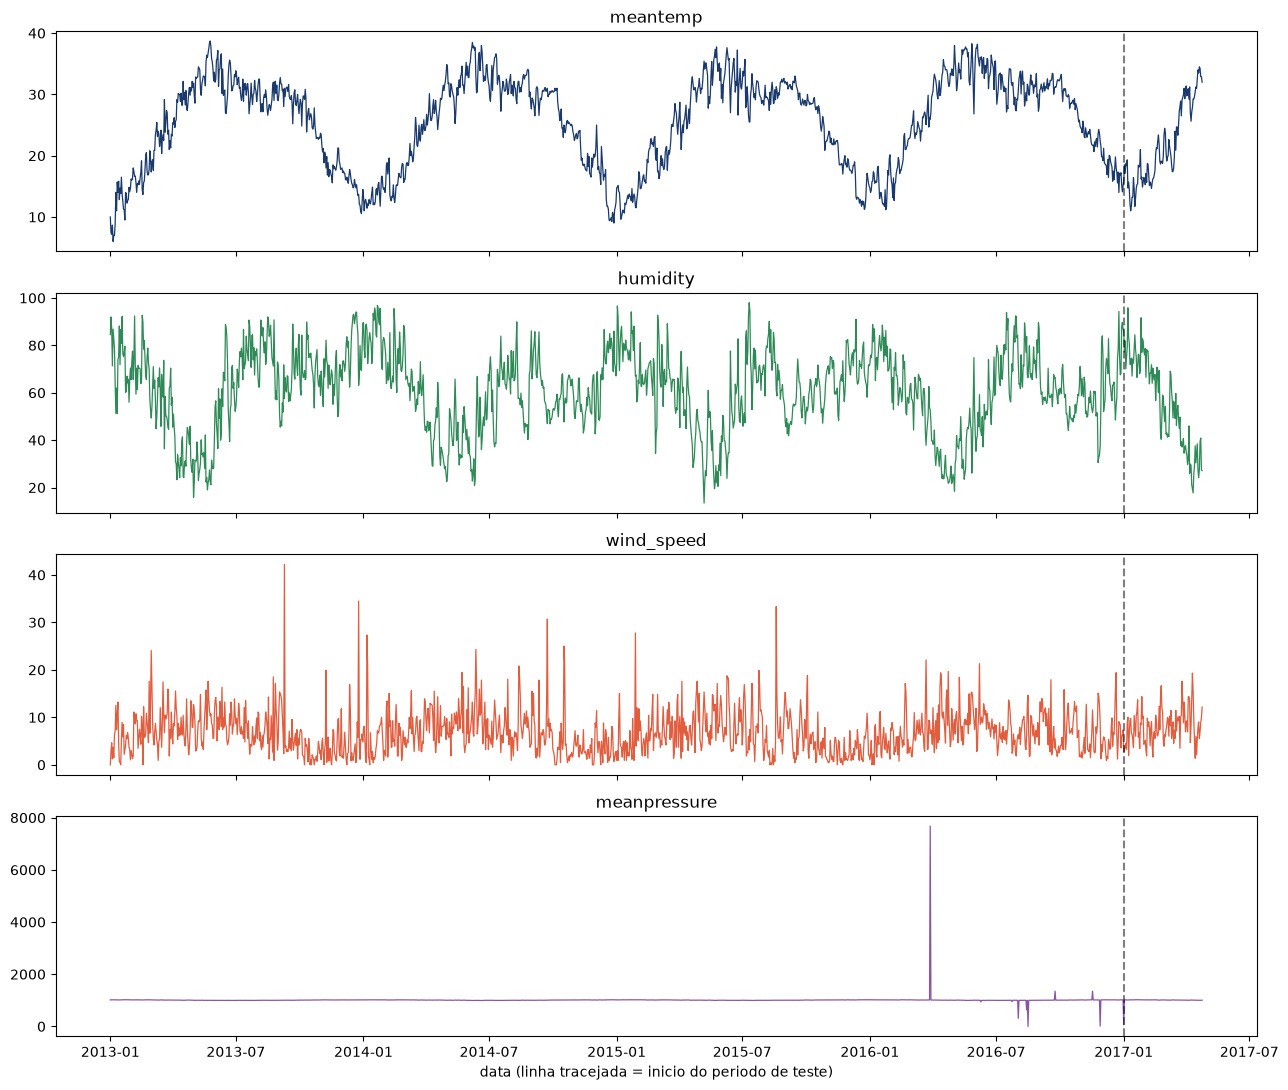

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for ax, col, color in zip(axes, ["meantemp", "humidity", "wind_speed", "meanpressure"],
                           ["#1a3a6e", "#2e8b57", "#e25c3e", "#8856a7"]):
    ax.plot(raw.index, raw[col], color=color, linewidth=0.9)
    ax.set_title(col)
    ax.axvline(pd.Timestamp("2017-01-01"), color="black", linestyle="--", alpha=0.5)
axes[-1].set_xlabel("data (linha tracejada = inicio do periodo de teste)")
plt.tight_layout()
plt.show()

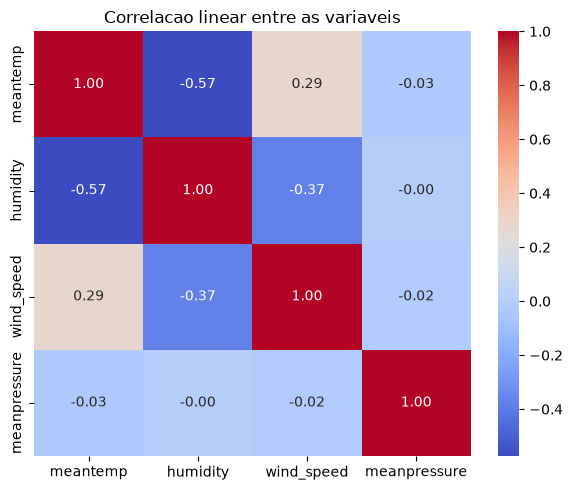

In [4]:
corr = raw.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlacao linear entre as variaveis")
plt.tight_layout()
plt.show()

**Outliers e irregularidades encontrados:**
- `meanpressure` tem ~10 valores fisicamente implausiveis (ex.: `-3.04`, `7679.33` hPa,
  misturados com o range normal ~990-1023 hPa) — ja documentado em `GRUPO1.md`.
- A data `2017-01-01` aparece nos dois arquivos (ultima linha do treino e primeira do
  teste) com valores **diferentes** — tratado na limpeza (Secao C) mantendo a versao do
  arquivo de teste, por ser a fronteira oficial do periodo avaliado.
- Sem gaps de frequencia: a uniao treino+teste cobre todos os dias do periodo.

## C. Limpeza

In [5]:
cleaned, decisions = tc.clean_series(raw)
display(decisions)
print("Range de meanpressure apos limpeza:", cleaned["meanpressure"].min(), "-", cleaned["meanpressure"].max())
print("NaN residual:", cleaned.isna().sum().sum())

cleaned.to_csv(DATA_DIR / f"cleaned_{BASE_ID}.csv")
decisions.to_csv(DATA_DIR / f"cleaning_decisions_{BASE_ID}.csv", index=False)
print("Salvo:", DATA_DIR / f"cleaned_{BASE_ID}.csv")

,Etapa,Decisao,Justificativa
0,Frequencia,asfreq('D'),Serie diaria continua (sem gaps na uniao trein...
1,Outliers meanpressure,"Fora de [990.0, 1040.0] hPa -> NaN -> interpol...","10 valores implausiveis (ex.: -3.04, 7679.33) ..."
2,Missing residual,0 -> 0,Interpolacao temporal cobre gaps pontuais


Range de meanpressure apos limpeza: 991.375 - 1023.0
NaN residual: 0
Salvo: ..\data\base_01\cleaned_base_01.csv


## D. STL e sazonalidade (§5.2)

Comparamos a forca de sazonalidade ($F_s$) entre candidatos compativeis com dado diario:
semanal (`m=7`), mensal (`m=30`) e anual (`m=365`), no mesmo espirito da Secao 4 do notebook
de referencia SARIMAX.

$$F_s = \max\left(0,\; 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t + R_t)}\right)$$

In [6]:
forcas = {m: tc.seasonal_strength(cleaned["meantemp"], period=m) for m in (7, 30, 365)}
forcas_df = pd.Series(forcas, name="Fs").sort_values(ascending=False).to_frame()
display(forcas_df.round(4))

,Fs
365,0.9330
30,0.2866
7,0.0430


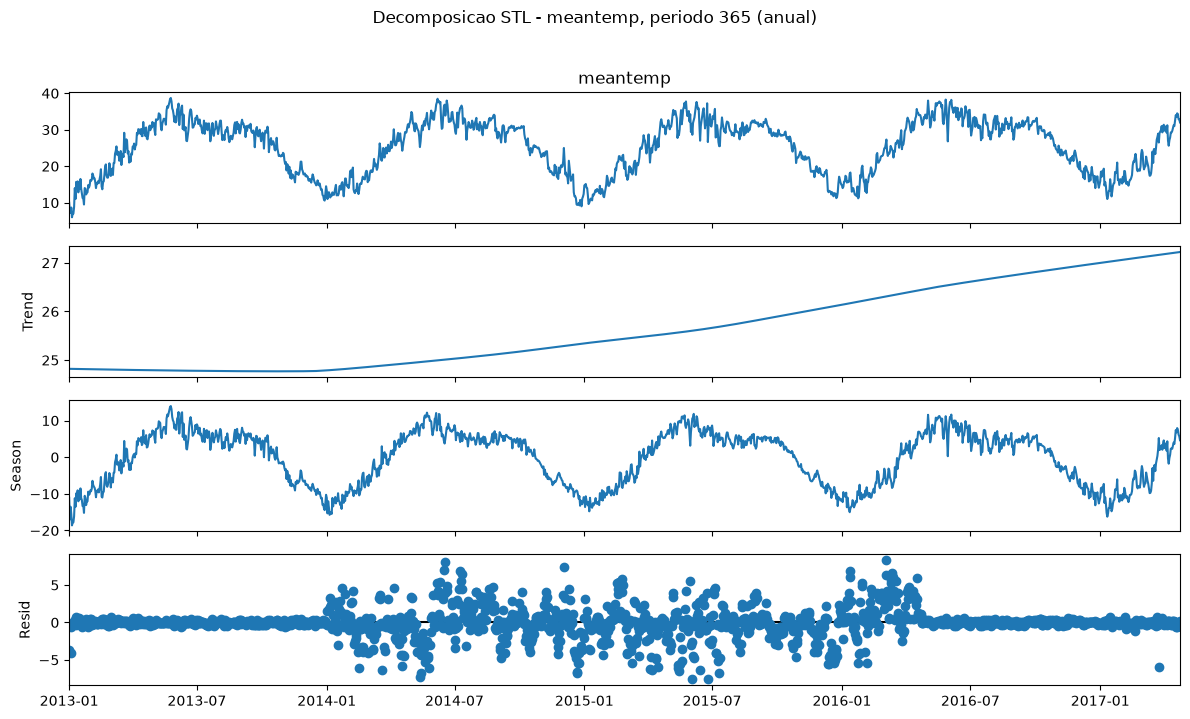

In [7]:
from statsmodels.tsa.seasonal import STL
stl_365 = STL(cleaned["meantemp"], period=365, robust=True).fit()
fig = stl_365.plot()
fig.set_size_inches(12, 7)
plt.suptitle("Decomposicao STL - meantemp, periodo 365 (anual)", y=1.02)
plt.tight_layout()
plt.show()

**A sazonalidade anual eh real ou um artefato do STL?** Tres evidencias que nao dependem do STL,
calculadas so com o periodo pre-teste (ate 2016-12-31):

1. **Sobreposicao dos anos por dia do ano** — se ha ciclo anual, as curvas de anos diferentes se sobrepoem.
2. **Distribuicao por mes** — um ciclo anual aparece como um perfil mensal com amplitude muito
   maior que a dispersao dentro de cada mes.
3. **ACF ate 400 lags** — um ciclo anual gera autocorrelacao positiva em torno do lag 365 e
   negativa em torno do lag 182 (meio ciclo).

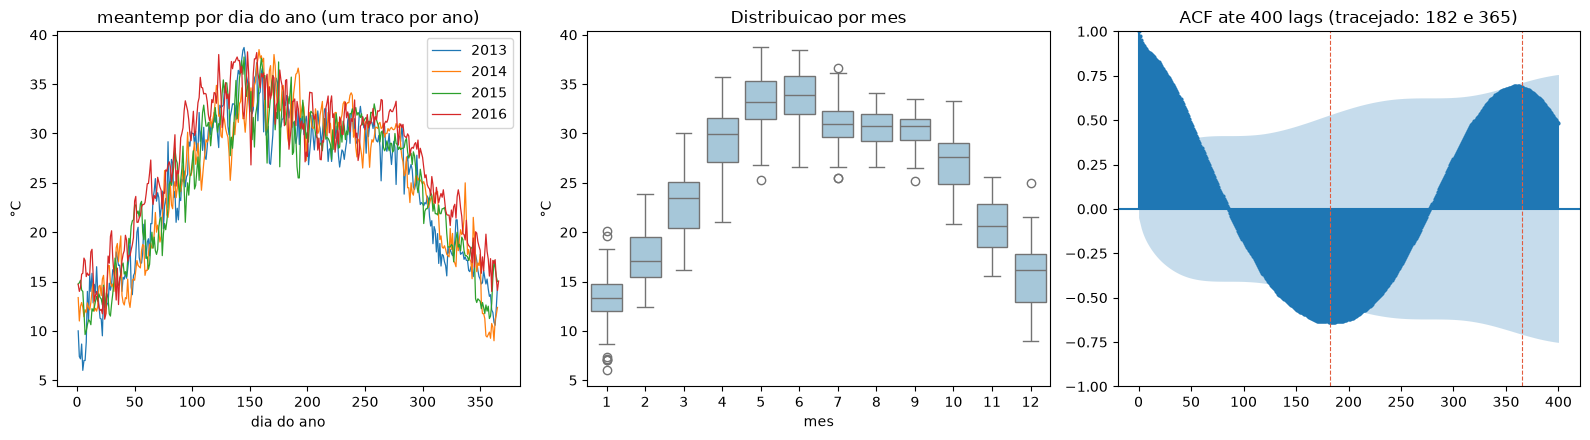

,ACF
lag 7,0.899
lag 30,0.726
lag 182,-0.636
lag 365,0.684


Media mensal (°C) por ano:


date,2013,2014,2015,2016
date,,,,
1,12.1,13.4,12.7,15.1
2,16.9,15.7,18.8,19.0
3,22.8,21.6,21.5,25.7
4,28.9,28.1,28.0,32.6
5,33.8,31.4,33.4,34.7
6,32.5,34.8,32.7,34.9
7,30.7,32.0,30.4,30.9
8,29.5,31.4,30.3,31.1
9,29.8,29.8,30.6,31.5


Correlacao entre os perfis mensais de cada ano:


date,2013,2014,2015,2016
date,,,,
2013,1.000,0.981,0.991,0.990
2014,0.981,1.000,0.982,0.974
2015,0.991,0.982,1.000,0.981
2016,0.990,0.974,0.981,1.000


In [8]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

y_pre = cleaned.loc[:"2016-12-31", tc.TARGET]  # so o periodo pre-teste

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for year, grp in y_pre.groupby(y_pre.index.year):
    axes[0].plot(grp.index.dayofyear, grp.values, linewidth=0.9, label=str(year))
axes[0].set_title("meantemp por dia do ano (um traco por ano)")
axes[0].set_xlabel("dia do ano")
axes[0].set_ylabel("°C")
axes[0].legend()
sns.boxplot(x=y_pre.index.month, y=y_pre.values, ax=axes[1], color="#9ecae1")
axes[1].set_title("Distribuicao por mes")
axes[1].set_xlabel("mes")
axes[1].set_ylabel("°C")
plot_acf(y_pre, lags=400, ax=axes[2], markersize=2)
for lag in (182, 365):
    axes[2].axvline(lag, color="#e25c3e", linestyle="--", linewidth=0.8)
axes[2].set_title("ACF ate 400 lags (tracejado: 182 e 365)")
plt.tight_layout()
plt.show()

acf_vals = acf(y_pre, nlags=365)
display(pd.Series({f"lag {k}": acf_vals[k] for k in (7, 30, 182, 365)}, name="ACF").round(3).to_frame())
monthly = y_pre.groupby([y_pre.index.year, y_pre.index.month]).mean().unstack(0)
print("Media mensal (°C) por ano:")
display(monthly.round(1))
print("Correlacao entre os perfis mensais de cada ano:")
display(monthly.corr().round(3))

**Decisao (m sazonal): `m=365`.** A sazonalidade anual esta comprovada por quatro evidencias
independentes:

- **Forca de sazonalidade** `Fs=0.93` em `m=365`, contra `0.29` em `m=30` e `0.04` em `m=7`.
- **ACF** de `0.68` no lag 365 e de `-0.64` no lag 182: o meio do ano eh o oposto do inicio,
  assinatura de um ciclo anual.
- **Amplitude do perfil mensal** de ~20 °C (media de ~13 °C em janeiro a ~34 °C em junho), muito
  maior que a dispersao dentro de cada mes.
- **Repetibilidade:** os perfis mensais dos 4 anos tem correlacao de 0.97 a 0.99 entre si. O
  que muda de ano para ano eh o nivel (2016 foi ~2 °C mais quente que 2013-2014 na maior parte
  dos meses), nao o formato do ciclo.

O ACF alto em lag 7 (`0.90`) **nao** indica ciclo semanal: eh a persistencia diaria da
temperatura (o ACF decai devagar de lag 1 em diante), coerente com o `Fs(7)=0.04`. O `Fs` de
`m=30` tambem nao corresponde a um ciclo fisico mensal; provavelmente o STL com janela curta
absorve parte da curva anual.

Consequencias para os modelos (detalhes na Secao F):

- **Holt-Winters:** `seasonal_periods=365` fixo (custo linear em `m`, viavel).
- **SARIMAX:** um `seasonal_order=(P,D,Q,365)` literal cria ~366 estados no filtro de Kalman;
  a Secao F.1 mede esse custo e mostra que ele eh inviavel no walk-forward. O ciclo anual entra
  por **termos de Fourier** (regressao harmonica dinamica — Hyndman & Athanasopoulos, *FPP*,
  2a ed., §9.5) **ou** por **diferenciacao sazonal anual** (`D=1`, `m=365`, feita
  manualmente); o grid escolhe entre as duas vias e o numero de harmonicos. Os termos sazonais
  `(P,D,Q)` literais sao buscados nos periodos em que o SARIMAX eh viavel (`m=7` e `m=30`).

## E. Feature engineering (§5.3, ADR-0003)

Vetor tabular unico para Random Forest e Elastic Net: lags do alvo, lags das externas
(`lag_only` — nunca o valor do dia previsto), janelas moveis fechadas no passado e
calendario ciclico (`sin`/`cos` do dia do ano e do dia da semana). Ver
`notebooks/ts_common.py::build_features`.

**SARIMAX:** exogena candidata = termos de Fourier anuais (`known_ahead`) e/ou lag-1 das
externas (`lag_only`, congelado no ultimo valor conhecido para os passos futuros do
horizonte — ver `sarimax_future_exog`); a combinacao final sai da busca da Secao F.1.
**Holt-Winters:** somente `meantemp` (univariado).

In [9]:
features = tc.build_features(cleaned)
feature_cols_preview = [c for c in features.columns if c != tc.TARGET]
print("Features:", feature_cols_preview)
print("Shape (com NaN do inicio da serie):", features.shape, "| sem NaN:", features.dropna().shape)
features.to_parquet(DATA_DIR / f"features_{BASE_ID}.parquet")
print("Salvo:", DATA_DIR / f"features_{BASE_ID}.parquet")

Features: ['meantemp_lag_1', 'meantemp_lag_2', 'meantemp_lag_3', 'meantemp_lag_7', 'meantemp_lag_14', 'meantemp_lag_21', 'meantemp_lag_30', 'meantemp_lag_365', 'humidity_lag_1', 'humidity_lag_7', 'humidity_lag_14', 'wind_speed_lag_1', 'wind_speed_lag_7', 'wind_speed_lag_14', 'meanpressure_lag_1', 'meanpressure_lag_7', 'meanpressure_lag_14', 'meantemp_roll_mean_7', 'meantemp_roll_std_7', 'meantemp_roll_mean_30', 'meantemp_roll_std_30', 'day_of_year', 'month', 'day_of_week', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos']
Shape (com NaN do inicio da serie): (1575, 29) | sem NaN: (1210, 29)
Salvo: ..\data\base_01\features_base_01.parquet


In [10]:
feat_only = features.drop(columns=tc.TARGET)
nan_table = pd.DataFrame({
    "linhas_nan": feat_only.isna().sum(),
    "primeira_data_valida": feat_only.apply(lambda s: s.first_valid_index().date()),
}).sort_values("linhas_nan", ascending=False)
display(nan_table[nan_table["linhas_nan"] > 0])

first_complete = features.dropna().index.min()
assert features.loc[first_complete:].isna().sum().sum() == 0, "NaN fora do inicio da serie"
pre_test = features.loc[:"2016-12-31"]
n_drop = len(pre_test) - len(pre_test.dropna())
n_drop_sem_365 = len(pre_test) - len(pre_test.drop(columns="meantemp_lag_365").dropna())
print(f"NaN so no inicio da serie (primeira linha completa: {first_complete.date()})")
print(f"Pre-teste: {len(pre_test)} linhas | completas: {len(pre_test) - n_drop} | descartadas: {n_drop} ({n_drop / len(pre_test):.1%})")
print(f"Sem meantemp_lag_365 seriam descartadas: {n_drop_sem_365}")

,linhas_nan,primeira_data_valida
meantemp_lag_365,365,2014-01-01
meantemp_lag_30,30,2013-01-31
meantemp_roll_std_30,30,2013-01-31
meantemp_roll_mean_30,30,2013-01-31
meantemp_lag_21,21,2013-01-22
meanpressure_lag_14,14,2013-01-15
humidity_lag_14,14,2013-01-15
meantemp_lag_14,14,2013-01-15
wind_speed_lag_14,14,2013-01-15
humidity_lag_7,7,2013-01-08


NaN so no inicio da serie (primeira linha completa: 2014-01-01)
Pre-teste: 1461 linhas | completas: 1096 | descartadas: 365 (25.0%)
Sem meantemp_lag_365 seriam descartadas: 30


**Tratamento dos NaN gerados por lags e janelas (§5.3).**

- **Origem:** um lag `k` deixa as `k` primeiras linhas sem valor; uma janela de `w` dias (com
  `shift(1)` antes do `rolling`) deixa `w`. Uma linha so entra no treino com **todas** as features
  preenchidas, entao o que manda eh a feature mais longa: `meantemp_lag_365`.
- **Tratamento: descarte (`dropna`), sem imputacao.** No pre-teste (ate 2016-12-31) sao 1461
  linhas, das quais 1096 ficam completas: **365 linhas descartadas (25%)**, o ano de 2013 inteiro.
  Em cada origem do walk-forward o descarte eh o mesmo (os 365 primeiros dias do treino), e a
  assercao acima garante que os NaN existem so no inicio da serie, entao o descarte nao abre
  buracos no meio dela.
- **Por que descartar em vez de imputar:** imputar o `lag_365` de 2013 exigiria inventar a
  temperatura de 2012, que nao existe na base (vedado no plano: nao inventar observacoes). Um
  `bfill` nas janelas iniciais copiaria valores **posteriores** a data (vazamento); um `ffill` nao
  tem valor anterior para copiar. Pelo mesmo motivo, o SARIMAX descarta a primeira linha (sem
  lag-1 das externas) em vez de preenche-la.
- **Por que manter o `lag_365` apesar do custo:** a Secao F.5 mede isso na validacao, com os HP
  ja escolhidos. Sem ele, o descarte cairia para 30 linhas (o `lag_30` e as janelas de 30 dias
  passam a mandar), mas o MAE **piora** tanto no Random Forest quanto no Elastic Net: a memoria
  anual (temperatura do mesmo dia no ano anterior) vale mais que o ano extra de treino.
- **Na previsao nao ha NaN:** os lags do alvo vem do historico ou das proprias previsoes
  (recursivo), e o `lag_365` de qualquer data prevista (`h <= 7`) aponta para um dia ja observado.

**Checklist anti-leakage:**
- [x] Lags do alvo e das externas usam somente `shift(>=1)`
- [x] Janelas moveis calculadas sobre a serie ja deslocada 1 passo (`shift(1)` antes do `rolling`)
- [x] Calendario (`day_of_year`, `month`, `dow`, senoides) e deterministico na data prevista — `known_ahead`
- [x] Externas (`humidity`, `wind_speed`, `meanpressure`) nunca entram com o valor do dia previsto
- [x] `StandardScaler` (Elastic Net) ajustado somente no treino de cada origem do walk-forward

## F. Hiperparametros (§5.5) e walk-forward (§5.4-5.6)

**Horizonte e origens (Secao 2.3 do plano):** adotamos a fronteira oficial do Kaggle
(2017-01-01) como periodo de teste congelado (~114 dias), `h=7` dias, `origin_step=7`
(origens nao sobrepostas). A validacao interna (tuning) usa os ~114 dias imediatamente
anteriores ao teste, no mesmo espirito subtreino/validacao do notebook de referencia
SARIMAX. Os quatro modelos usam **as mesmas origens e o mesmo `h`**.

In [11]:
TEST_START = pd.Timestamp("2017-01-01")
TEST_END = pd.Timestamp("2017-04-24")
H = 7
FIRST_ORIGIN_TEST = TEST_START - pd.Timedelta(days=1)
LAST_ORIGIN_TEST = TEST_END - pd.Timedelta(days=H)
cfg_test = tc.WalkForwardConfig(horizon=H, origin_step=7, first_origin=FIRST_ORIGIN_TEST, last_origin=LAST_ORIGIN_TEST)

VAL_END = FIRST_ORIGIN_TEST
VAL_LEN = (TEST_END - TEST_START).days + 1
VAL_START = VAL_END - pd.Timedelta(days=VAL_LEN - 1)
FIRST_ORIGIN_VAL = VAL_START - pd.Timedelta(days=1)
LAST_ORIGIN_VAL = VAL_END - pd.Timedelta(days=H)
# origin_step maior no tuning (6 origens em vez de 16) -- mantem o mesmo h/protocolo mas
# reduz o custo computacional da busca de hiperparametros (o walk-forward final de teste,
# abaixo, sim usa as 16 origens completas com os HP ja fixados).
cfg_tune = tc.WalkForwardConfig(horizon=H, origin_step=21, first_origin=FIRST_ORIGIN_VAL, last_origin=LAST_ORIGIN_VAL)

subtrain_plus_val = cleaned.loc[:VAL_END]
full_train = cleaned.loc[:FIRST_ORIGIN_TEST]

print("Periodo de teste:", TEST_START.date(), "a", TEST_END.date())
print("Origens de teste:", len(tc.build_origins(cfg_test)), "| origens de tuning (validacao):", len(tc.build_origins(cfg_tune)))

Periodo de teste: 2017-01-01 a 2017-04-24
Origens de teste: 16 | origens de tuning (validacao): 6


**Procedimento comum de otimizacao (§5.5).** Todo candidato eh avaliado pelo **mesmo protocolo
do teste**: walk-forward nas 6 origens de validacao (`h=7`, ~114 dias imediatamente anteriores
ao teste), ranqueado pelo MAE agregado. O periodo de teste nao participa de nenhuma decisao; os
HP vencedores ficam fixos no walk-forward final.

- **Criterio principal = MAE de validacao, nao AIC/BIC.** O MAE eh a metrica do trabalho
  (ADR-0001) e vale para os quatro modelos, e mede exatamente o que sera avaliado (erro fora da
  amostra em `h=7`). AIC/BIC so existem para SARIMAX e Holt-Winters e so sao comparaveis entre
  candidatos ajustados sobre **a mesma serie** (mesmo `d`, mesma diferenciacao sazonal, mesmo
  numero de observacoes). Reportamos AIC/BIC de um ajuste unico com os dados ate a primeira
  origem de validacao, como evidencia complementar.
- **6 origens no tuning (`origin_step=21`)** em vez de 16: reduz o custo da busca mantendo o
  mesmo `h` e a mesma regra de refit do teste.
- A coluna `segundos` registra o custo de cada candidato (6 refits + previsoes).

| Modelo | Estrategia | Espaco investigado | Candidatos |
|--------|-----------|---------------------|-----------:|
| SARIMAX | grid em 4 etapas (busca coordenada) | `(p,d,q)`; Fourier `K` ou `D=1` com `m=365`; `(P,D,Q)` com `m` em {7,30}; lags das externas (medido, mantido por exigencia do §3) | 41 |
| Holt-Winters | grid completo | `trend` em {None, add, add amortecida} x `seasonal` em {None, add, mul}; `m=365` fixo (7 e 30 so como comparacao); suavizacao estimada | 21 |
| Random Forest | busca aleatoria | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` | 31 |
| Elastic Net | grid completo | `alpha` (escala log) x `l1_ratio` | 36 |

A justificativa de cada espaco esta na subsecao do modelo.

In [12]:
import time
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# AIC/BIC: ajuste unico com os dados ate a primeira origem de validacao (nada da validacao/teste)
ic_train = subtrain_plus_val.loc[:FIRST_ORIGIN_VAL]

def sarimax_factory(params):
    def _fn(train_df, horizon):
        res = tc.fit_sarimax(train_df, params)
        return tc.forecast_sarimax(res, train_df, params, horizon)
    return _fn

def sarimax_ic(params):
    res = tc.fit_sarimax(ic_train, params)
    return {"aic": res.aic, "bic": res.bic, "n_obs": int(res.nobs)}

def fit_hw(y, params):
    return ExponentialSmoothing(y, trend=params["trend"], damped_trend=params["damped"],
                                seasonal=params["seasonal"], seasonal_periods=params["seasonal_periods"],
                                initialization_method="heuristic").fit()

def hw_factory(params):
    def _fn(train_df, horizon):
        return fit_hw(train_df[tc.TARGET], params).forecast(horizon).to_numpy()
    return _fn

def hw_ic(params):
    res = fit_hw(ic_train[tc.TARGET], params)
    # nomes gregos para nao colidir com as colunas trend/seasonal da configuracao
    smooth = {g: res.params[k] for g, k in (("alpha", "smoothing_level"), ("beta", "smoothing_trend"), ("gamma", "smoothing_seasonal"))}
    return {"aic": res.aic, "bic": res.bic, **smooth}

def rf_factory(params):
    def _fn(train_df, horizon):
        feat_all = tc.build_features(train_df).dropna()
        feature_cols = [c for c in feat_all.columns if c != tc.TARGET]
        X, y = feat_all[feature_cols], feat_all[tc.TARGET]
        model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **params).fit(X, y)
        return tc.recursive_tabular_forecast(model, feature_cols, train_df, horizon)
    return _fn

def en_factory(params):
    def _fn(train_df, horizon):
        feat_all = tc.build_features(train_df).dropna()
        feature_cols = [c for c in feat_all.columns if c != tc.TARGET]
        X, y = feat_all[feature_cols], feat_all[tc.TARGET]
        model = make_pipeline(StandardScaler(), ElasticNet(random_state=RANDOM_STATE, max_iter=10000, **params)).fit(X, y)
        return tc.recursive_tabular_forecast(model, feature_cols, train_df, horizon)
    return _fn

tuning_tables = {}

### F.1 SARIMAX

**Custo de um `seasonal_order` literal.** O SARIMAX do statsmodels roda num filtro de Kalman
cujo estado cresce com `m`: com `P=1` ou `Q=1`, sao ~`m+1` estados, e cada avaliacao da
verossimilhanca custa aproximadamente o quadrado disso. A celula abaixo mede uma unica avaliacao
para cada `m` candidato.

In [13]:
custo = []
exog_custo = tc.sarimax_exog(ic_train, n_harmonics=0, use_lags=True).iloc[1:]  # 1a linha sem lag
for m in (7, 30, 365):
    mod = SARIMAX(ic_train[tc.TARGET].iloc[1:], exog=exog_custo, order=(0, 1, 0), seasonal_order=(1, 0, 0, m),
                  enforce_stationarity=False, enforce_invertibility=False)
    t0 = time.time()
    mod.loglike(mod.start_params)
    custo.append({"m": m, "estados_kalman": mod.k_states, "seg_por_avaliacao": round(time.time() - t0, 3)})
display(pd.DataFrame(custo))

,m,estados_kalman,seg_por_avaliacao
0,7,8,0.008
1,30,31,0.011
2,365,366,8.432


Com `m=365` uma **unica** avaliacao leva segundos, e o ajuste por maxima verossimilhanca precisa de
centenas delas: medido fora deste notebook, um unico ajuste `(0,1,0)x(1,0,0,365)` com os dados ate
a validacao foi interrompido apos 9 minutos sem convergir. O grid de `(P,D,Q)` com `m=365` exigiria
8 combinacoes x 6 origens de validacao + 16 origens de teste — dias de processamento. Por isso:

- `P` e `Q` com `m=365` ficam **fora** da busca (inviaveis);
- `D=1` com `m=365` **entra**, feito manualmente (`y_t - y_{t-365}`), o que nao cria estados;
- o ciclo anual pode entrar tambem por **Fourier** (alternativa padrao para periodos longos);
- `(P,D,Q)` completo eh buscado em `m=7` e `m=30`, onde o custo eh de centesimos de segundo.

**Busca em etapas (coordenada).** O grid conjunto (18 ordens x 6 tratamentos anuais x 15 sazonais
x 2 exogenas ~ 3200 candidatos x 6 refits) seria inviavel. Buscamos uma dimensao por vez, fixando
as demais no melhor valor da etapa anterior, da mais para a menos estrutural:

1. **`(p,d,q)`** em {0,1,2} x {0,1} x {0,1,2}. Ate 2 termos AR/MA cobrem a dependencia de curto
   prazo de uma serie diaria; ordens maiores aumentam o risco de nao convergencia sem ganho
   esperado. `d` em {0,1}: o nivel da serie vaga ao longo do ano; `d=2` superdiferenciaria.
   Exogena de referencia nesta etapa: Fourier `K=2` + lags das externas.
2. **Ciclo anual (`m=365`)**: Fourier com `K` em {0,1,2,3,4} harmonicos (`K=0` = sem tratamento
   anual, linha de base) **ou** `D=1` com `m=365`. Mais de 4 harmonicos passaria a modelar
   oscilacoes de poucas semanas, que a forca de sazonalidade nao sustenta.
3. **`(P,D,Q)` sazonal** em {0,1}^3 com `m` em {7, 30}: verifica se ha estrutura semanal/mensal
   alem do ciclo anual. Com `Fs` de 0.04 e 0.29, o ganho esperado eh pequeno — o grid confirma.
   Ordens sazonais > 1 ficam de fora pelo mesmo motivo de `p,q <= 2`.
4. **Variaveis externas**: com e sem o lag-1 de `humidity`/`wind_speed`/`meanpressure` (unica
   forma sem vazamento, Secao 2.2 do plano). Esta etapa **mede** o efeito das externas; o modelo
   final as mantem, porque o §3 do enunciado exige que o SARIMAX incorpore as variaveis externas
   compativeis com o algoritmo.

**Leitura do AIC/BIC:** so compare candidatos com o mesmo `d` e o mesmo `annual_diff` (a coluna
`n_obs` mostra quando a amostra muda — `D=1` com `m=365` perde o primeiro ano).

In [14]:
sx_base = {"order": (0, 1, 0), "seasonal_order": (0, 0, 0, 0), "fourier_k": 2, "annual_diff": False, "exog_lags": True}
sx_cols = ["order", "seasonal_order", "fourier_k", "annual_diff", "exog_lags", "mae_validacao", "aic", "bic", "n_obs", "segundos", "status"]

# Etapa 1 -- ordem nao sazonal
sx_stage1 = [{**sx_base, "order": (p, d, q)} for p in (0, 1, 2) for d in (0, 1) for q in (0, 1, 2)]
sx_tuning1 = tc.tune_by_walkforward(sx_stage1, sarimax_factory, subtrain_plus_val, cfg_tune, ic_fn=sarimax_ic, n_jobs=N_JOBS)
best_s1 = sx_stage1[int(sx_tuning1.iloc[0]["candidato"])]
display(sx_tuning1[sx_cols].head(8))
print("Menor AIC dentro de cada d (AIC so eh comparavel no mesmo d):")
display(sx_tuning1.loc[sx_tuning1.groupby(sx_tuning1["order"].map(lambda o: o[1]))["aic"].idxmin(), sx_cols])
print("Etapa 1 ->", best_s1["order"])

,order,seasonal_order,fourier_k,annual_diff,exog_lags,mae_validacao,aic,bic,n_obs,segundos,status
0,"(0, 1, 0)","(0, 0, 0, 0)",2,False,True,0.801536,5211.552877,5253.180121,1346,7.9,ok
1,"(1, 1, 0)","(0, 0, 0, 0)",2,False,True,0.817026,5198.463346,5245.293996,1346,7.3,ok
2,"(0, 1, 1)","(0, 0, 0, 0)",2,False,True,0.838950,5181.951838,5228.775789,1346,15.6,ok
3,"(2, 1, 0)","(0, 0, 0, 0)",2,False,True,0.856730,5178.882173,5230.908784,1346,7.6,ok
4,"(0, 1, 2)","(0, 0, 0, 0)",2,False,True,0.918032,5136.424392,5188.443555,1346,27.7,ok
5,"(2, 1, 2)","(0, 0, 0, 0)",2,False,True,0.920084,5025.968851,5088.391847,1346,49.1,ok
6,"(1, 1, 1)","(0, 0, 0, 0)",2,False,True,0.935214,5029.342914,5081.369526,1346,24.2,ok
7,"(1, 1, 2)","(0, 0, 0, 0)",2,False,True,0.937003,5024.854439,5082.075519,1346,33.2,ok


Menor AIC dentro de cada d (AIC so eh comparavel no mesmo d):


,order,seasonal_order,fourier_k,annual_diff,exog_lags,mae_validacao,aic,bic,n_obs,segundos,status
10,"(1, 0, 2)","(0, 0, 0, 0)",2,False,True,1.452213,5038.960201,5096.189474,1346,45.6,ok
7,"(1, 1, 2)","(0, 0, 0, 0)",2,False,True,0.937003,5024.854439,5082.075519,1346,33.2,ok


Etapa 1 -> (0, 1, 0)


In [15]:
# Etapa 2 -- tratamento do ciclo anual (m=365)
sx_stage2 = [{**best_s1, "fourier_k": k, "annual_diff": False} for k in (0, 1, 2, 3, 4)]
sx_stage2.append({**best_s1, "fourier_k": 0, "annual_diff": True})
sx_tuning2 = tc.tune_by_walkforward(sx_stage2, sarimax_factory, subtrain_plus_val, cfg_tune, ic_fn=sarimax_ic, n_jobs=N_JOBS)
best_s2 = sx_stage2[int(sx_tuning2.iloc[0]["candidato"])]
display(sx_tuning2[sx_cols])
print("Etapa 2 ->", {k: best_s2[k] for k in ("fourier_k", "annual_diff")})

,order,seasonal_order,fourier_k,annual_diff,exog_lags,mae_validacao,aic,bic,n_obs,segundos,status
0,"(0, 1, 0)","(0, 0, 0, 0)",2,False,True,0.801536,5211.552877,5253.180121,1346,7.8,ok
1,"(0, 1, 0)","(0, 0, 0, 0)",4,False,True,0.805392,5218.787861,5281.228727,1346,12.4,ok
2,"(0, 1, 0)","(0, 0, 0, 0)",3,False,True,0.824136,5214.895336,5266.929391,1346,10.4,ok
3,"(0, 1, 0)","(0, 0, 0, 0)",1,False,True,0.941480,5210.355810,5241.576243,1346,6.6,ok
4,"(0, 1, 0)","(0, 0, 0, 0)",0,False,True,1.143141,5212.862110,5233.675732,1346,4.7,ok
5,"(0, 1, 0)","(0, 0, 0, 0)",0,True,True,1.520287,4468.011239,4487.557366,981,4.5,ok


Etapa 2 -> {'fourier_k': 2, 'annual_diff': False}


In [16]:
# Etapa 3 -- (P,D,Q) sazonal nos periodos viaveis
sx_stage3 = [{**best_s2, "seasonal_order": (0, 0, 0, 0)}]
sx_stage3 += [{**best_s2, "seasonal_order": (P, D, Q, m)}
              for m in (7, 30) for P in (0, 1) for D in (0, 1) for Q in (0, 1) if (P, D, Q) != (0, 0, 0)]
sx_tuning3 = tc.tune_by_walkforward(sx_stage3, sarimax_factory, subtrain_plus_val, cfg_tune, ic_fn=sarimax_ic, n_jobs=N_JOBS)
best_s3 = sx_stage3[int(sx_tuning3.iloc[0]["candidato"])]
display(sx_tuning3[sx_cols])
print("Etapa 3 ->", best_s3["seasonal_order"])

,order,seasonal_order,fourier_k,annual_diff,exog_lags,mae_validacao,aic,bic,n_obs,segundos,status
0,"(0, 1, 0)","(1, 0, 1, 7)",2,False,True,0.785686,5174.800707,5226.782543,1346,27.0,ok
1,"(0, 1, 0)","(0, 0, 1, 7)",2,False,True,0.792299,5174.746430,5221.530082,1346,10.1,ok
2,"(0, 1, 0)","(1, 0, 0, 7)",2,False,True,0.793883,5180.138587,5226.928969,1346,9.3,ok
3,"(0, 1, 0)","(0, 0, 0, 0)",2,False,True,0.801536,5211.552877,5253.180121,1346,9.3,ok
4,"(0, 1, 0)","(1, 0, 0, 30)",2,False,True,0.803691,5082.932636,5129.566963,1346,570.7,ok
5,"(0, 1, 0)","(1, 1, 1, 7)",2,False,True,0.803919,5183.316347,5235.245689,1346,90.0,ok
6,"(0, 1, 0)","(1, 0, 1, 30)",2,False,True,0.804796,5081.264532,5133.072844,1346,349.4,ok
7,"(0, 1, 0)","(0, 0, 1, 30)",2,False,True,0.804874,5079.801314,5126.428794,1346,626.7,ok
8,"(0, 1, 0)","(0, 1, 1, 7)",2,False,True,0.815902,5183.534313,5230.270721,1346,75.4,ok
9,"(0, 1, 0)","(0, 1, 1, 30)",2,False,True,0.867883,5063.348018,5109.767637,1346,1013.8,ok


Etapa 3 -> (1, 0, 1, 7)


In [17]:
# Etapa 4 -- variaveis externas
sx_stage4 = [{**best_s3, "exog_lags": lags} for lags in (True, False)]
sx_tuning4 = tc.tune_by_walkforward(sx_stage4, sarimax_factory, subtrain_plus_val, cfg_tune, ic_fn=sarimax_ic, n_jobs=N_JOBS)
# Decisao: exog_lags=True fixo -- o §3 do enunciado exige que o SARIMAX incorpore as externas
# compativeis. A etapa 4 fica como medida do efeito delas (ver leitura abaixo).
best_sarimax = {**best_s3, "exog_lags": True}
best_sarimax_mae = float(sx_tuning4.loc[sx_tuning4["exog_lags"], "mae_validacao"].iloc[0])
display(sx_tuning4[sx_cols])

tuning_tables["sarimax"] = pd.concat(
    [t.assign(etapa=i) for i, t in enumerate((sx_tuning1, sx_tuning2, sx_tuning3, sx_tuning4), start=1)],
    ignore_index=True,
)
print("Vencedor SARIMAX:", best_sarimax, "| MAE validacao:", round(best_sarimax_mae, 3))

,order,seasonal_order,fourier_k,annual_diff,exog_lags,mae_validacao,aic,bic,n_obs,segundos,status
0,"(0, 1, 0)","(1, 0, 1, 7)",2,False,False,0.774166,5204.273840,5240.666359,1347,10.8,ok
1,"(0, 1, 0)","(1, 0, 1, 7)",2,False,True,0.785686,5174.800707,5226.782543,1346,14.5,ok


Vencedor SARIMAX: {'order': (0, 1, 0), 'seasonal_order': (1, 0, 1, 7), 'fourier_k': 2, 'annual_diff': False, 'exog_lags': True} | MAE validacao: 0.786


**Leitura da busca SARIMAX:**

- **Etapa 1:** `(0,1,0)` vence por MAE (0.802). Modelos com mais termos AR/MA tem AIC bem menor
  (ex.: `(1,1,2)`, AIC 5025 contra 5212), mas erram mais em 7 passos (0.94). O AIC mede o ajuste
  um passo a frente dentro da amostra e premia termos que capturam a dinamica de curtissimo
  prazo; em 7 passos essa dinamica se dissipa e os termos extras so acrescentam variancia. Como o
  criterio do trabalho eh o erro em `h=7`, ficamos com o MAE. `d=1` domina `d=0` (o melhor `d=0`,
  `(1,0,2)`, tem MAE 1.45).
- **Etapa 2:** o tratamento anual eh essencial: sem Fourier o MAE vai a 1.14, com `K=1` cai
  para 0.94, e com `K` de 2 a 4 fica entre 0.80 e 0.82. `K=2` vence por margem minima sobre
  `K=4` (0.802 x 0.805). AIC/BIC preferem menos harmonicos (`K=1` no AIC, `K=0` no BIC), a mesma
  divergencia da etapa 1. A diferenciacao anual (`D=1`, `m=365`) fica bem pior (1.52): `y_t -
  y_{t-365}` carrega para a previsao o ruido do mesmo dia do ano anterior, e ainda perde o
  primeiro ano da amostra (`n_obs`=981, por isso o AIC dela nao eh comparavel).
- **Etapa 3:** o termo semanal `(1,0,1,7)` melhora pouco (0.802 -> 0.786), coerente com
  `Fs(7)=0.04`: ha alguma autocorrelacao residual no lag 7, mas nao um ciclo semanal.
  Diferenciar sazonalmente (`D=1`) piora sempre, e `m=30`, alem de nao ajudar, custa ate ~14 min
  por candidato.
- **Etapa 4:** sem os lags das externas o MAE de validacao cai de 0.786 para 0.774. Mantemos os
  lags no modelo final por exigencia do §3; a diferenca eh pequena (0.01 °C). Leitura: com
  `d=1`, o lag-1 de umidade, vento e pressao quase nao acrescenta informacao alem da propria
  temperatura de ontem. Os coeficientes sao retomados na Secao I.

**Configuracao final:** `(0,1,0)x(1,0,1,7)` + Fourier anual `K=2` + lag-1 das externas
(MAE de validacao 0.786).

### F.2 Holt-Winters

- **`trend`** em {None, aditiva, aditiva amortecida}. `None` testa se a serie precisa de tendencia
  (o STL mostrou tendencia fraca); a amortecida (`damped`) evita extrapolar uma inclinacao
  espuria ao longo dos 7 dias. **Tendencia multiplicativa excluida:** ela implica crescimento
  percentual composto, sem sentido fisico para temperatura em °C (escala intervalar, zero
  arbitrario).
- **`seasonal`** em {None, aditiva, multiplicativa}. `None` mede o ganho da sazonalidade. A
  multiplicativa supoe amplitude sazonal proporcional ao nivel, o que o mesmo argumento da escala
  °C torna improvavel, mas ela eh barata e fica no grid para o dado confirmar.
- **`seasonal_periods` (`m`) fixo em 365:** a sazonalidade anual esta comprovada na Secao D
  (Fs, ACF, perfis mensais). `m=7` e `m=30` (os demais candidatos do Fs) rodam na mesma grade
  **so como comparacao**; `trend`, `seasonal` e `damped` sao escolhidos entre os candidatos com
  `m=365`.
- **Parametros de suavizacao (`alpha`, `beta`, `gamma`) nao entram no grid:** o statsmodels os
  estima em cada ajuste minimizando o erro quadratico um passo a frente (equivalente a maxima
  verossimilhanca com erros gaussianos). Uma grade manual em [0,1]^3 seria mais grosseira que o
  otimizador. As colunas `alpha`, `beta` e `gamma` mostram os valores estimados (vazio = componente ausente).
- **`initialization_method='heuristic'`:** estados iniciais a partir dos 2 primeiros ciclos. A
  alternativa `estimated` otimizaria 365 estados sazonais iniciais junto com a suavizacao (alto
  risco de sobreajuste e custo alto); o treino tem ~3,7 ciclos anuais, suficientes para o
  heuristico (exige 2).
- **Sem Box-Cox:** a variancia de `meantemp` nao cresce com o nivel (grafico da Secao B).

In [18]:
hw_grid = [{"trend": t, "damped": dmp, "seasonal": s, "seasonal_periods": m}
           for t, dmp in ((None, False), ("add", False), ("add", True))
           for s, m in ((None, None), ("add", 7), ("mul", 7), ("add", 30), ("mul", 30), ("add", 365), ("mul", 365))]
hw_tuning = tc.tune_by_walkforward(hw_grid, hw_factory, subtrain_plus_val, cfg_tune, ic_fn=hw_ic, n_jobs=N_JOBS)
tuning_tables["holt_winters"] = hw_tuning
display(hw_tuning.drop(columns="candidato").round(4))

# m fixo em 365 (sazonalidade anual comprovada na Secao D): m=7/30 ficam na tabela como
# comparacao; trend/seasonal/damped sao escolhidos dentro de m=365.
hw_365 = hw_tuning[hw_tuning["seasonal_periods"] == 365]
best_hw = hw_grid[int(hw_365.iloc[0]["candidato"])]
best_hw_mae = float(hw_365.iloc[0]["mae_validacao"])
best_any = hw_tuning.iloc[0]
print("Melhor da grade inteira (so comparacao):", hw_grid[int(best_any["candidato"])], "| MAE", round(best_any["mae_validacao"], 3))
print("Vencedor Holt-Winters (m=365):", best_hw, "| MAE validacao:", round(best_hw_mae, 3))

,trend,damped,seasonal,seasonal_periods,mae_validacao,aic,bic,alpha,beta,gamma,status,segundos
0,add,False,add,7.0,0.9791,1491.2666,1548.5286,0.7523,0.0138,0.0360,ok,3.2
1,add,False,NaN,NaN,1.0269,1401.7900,1422.6125,0.7931,0.0061,NaN,ok,0.7
2,add,False,mul,7.0,1.0824,1597.0288,1654.2908,0.6791,0.0148,0.0995,ok,2.9
3,NaN,False,add,7.0,1.0964,1465.3444,1512.1951,0.7452,NaN,0.0361,ok,0.6
4,NaN,False,NaN,NaN,1.0968,1388.5529,1398.9641,0.7902,NaN,NaN,ok,0.2
5,add,True,add,7.0,1.0973,1469.1944,1531.6620,0.7434,0.0000,0.0361,ok,3.1
6,add,True,NaN,NaN,1.0974,1392.0396,1418.0678,0.7870,0.0000,NaN,ok,0.7
7,add,False,add,30.0,1.1006,1581.9352,1758.9268,0.7969,0.0040,0.0624,ok,3.5
8,add,False,mul,30.0,1.1187,1684.1836,1861.1752,0.7763,0.0037,0.0623,ok,3.2
9,NaN,False,add,30.0,1.1188,1569.6398,1736.2201,0.7931,NaN,0.0627,ok,0.4


Melhor da grade inteira (so comparacao): {'trend': 'add', 'damped': False, 'seasonal': 'add', 'seasonal_periods': 7} | MAE 0.979
Vencedor Holt-Winters (m=365): {'trend': 'add', 'damped': False, 'seasonal': 'add', 'seasonal_periods': 365} | MAE validacao: 1.204


**Leitura da busca Holt-Winters:**

- **Dentro de `m=365`:** vence tendencia aditiva sem amortecimento com sazonalidade aditiva
  (MAE 1.204). Amortecer ou tirar a tendencia muda pouco (1.215), e a sazonalidade
  multiplicativa perde (1.33), como esperado para temperatura em °C.
- **`m=7` teve MAE de validacao menor (0.979).** Isso nao contradiz a Secao D: com `Fs(7)=0.04`
  nao ha ciclo semanal, e o ganho sobre o modelo sem sazonalidade (1.027) eh pequeno. Num
  horizonte de 7 dias, o que pesa eh acompanhar o nivel recente (`alpha` ~ 0.75 em todos os
  candidatos), e o `m=7` faz isso sem carregar um perfil anual.
- **Por que o `m=365` rende menos do que o `Fs` sugere:** a suavizacao sazonal estimada eh
  `gamma=0` (e `beta=0`), entao o perfil anual fica congelado no que a inicializacao heuristica
  extraiu dos 2 primeiros anos. Com ~2 observacoes por dia do ano, cada um dos 365 indices
  sazonais carrega o ruido diario daqueles anos, e ele nunca se atualiza. AIC e BIC apontam na
  mesma direcao: penalizam os 365 estados sazonais.
- **Decisao:** `m=365` fixo, porque a sazonalidade anual esta comprovada; o custo em MAE de
  validacao frente ao `m=7` (1.204 x 0.979) fica documentado aqui.

### F.3 Random Forest

**Estrategia: busca aleatoria** (Bergstra & Bengio, 2012). O espaco abaixo tem 4x5x4x4x4 = 1280
combinacoes e cada candidato custa 6 refits + previsao recursiva de 7 passos, o que torna o grid
completo inviavel. A busca aleatoria com 30 sorteios (seed fixa) cobre melhor as dimensoes que
realmente importam do que um grid pequeno. A configuracao default do scikit-learn entra como
candidato de referencia.

- **`n_estimators`** em {100, 200, 400, 600}: mais arvores reduzem a variancia da media com retorno
  decrescente e nao causam sobreajuste; o limite eh o custo.
- **`max_depth`** em {6, 10, 14, 20, None}: complexidade de cada arvore; `None` = arvores
  completas (default).
- **`min_samples_split`** em {2, 5, 10, 20} e **`min_samples_leaf`** em {1, 2, 4, 8}: regularizam
  as folhas. Com ~1000 linhas de treino (o `lag_365` descarta o primeiro ano), folhas de ate 8
  amostras ainda preservam a granularidade sazonal.
- **`max_features`** em {1.0, 0.5, 'sqrt', 0.33}: fracao das 28 features sorteada a cada split.
  1.0 = bagging puro (default para regressao); valores menores decorrelacionam as arvores —
  relevante aqui porque `meantemp_lag_1` domina e tende a ocupar o topo de todas as arvores.

In [19]:
rf_space = {
    "n_estimators": [100, 200, 400, 600],
    "max_depth": [6, 10, 14, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [1.0, 0.5, "sqrt", 0.33],
}
rf_default = {"n_estimators": 100, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1, "max_features": 1.0}
rf_grid = [rf_default] + list(ParameterSampler(rf_space, n_iter=30, random_state=RANDOM_STATE))
rf_tuning = tc.tune_by_walkforward(rf_grid, rf_factory, subtrain_plus_val, cfg_tune, n_jobs=N_JOBS)
best_rf = rf_grid[int(rf_tuning.iloc[0]["candidato"])]
best_rf_mae = float(rf_tuning.iloc[0]["mae_validacao"])
tuning_tables["random_forest"] = rf_tuning
display(rf_tuning.drop(columns="candidato").head(10))
print("Posicao do default do sklearn:", int(rf_tuning.index[rf_tuning["candidato"] == 0][0]) + 1, "de", len(rf_tuning))
print("Vencedor Random Forest:", best_rf, "| MAE validacao:", round(best_rf_mae, 3))

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mae_validacao,status,segundos
0,600,NaN,5,1,sqrt,0.772259,ok,30.0
1,600,20.0,2,1,sqrt,0.773291,ok,33.8
2,600,14.0,5,8,sqrt,0.776189,ok,24.0
3,400,10.0,10,1,sqrt,0.787984,ok,22.0
4,200,10.0,5,2,sqrt,0.788191,ok,10.6
5,600,6.0,20,4,0.33,0.802384,ok,30.1
6,600,14.0,5,4,0.33,0.807161,ok,33.1
7,600,6.0,5,4,0.33,0.809630,ok,27.8
8,100,NaN,10,2,0.33,0.813227,ok,11.1
9,200,10.0,20,2,0.33,0.813955,ok,11.2


Posicao do default do sklearn: 28 de 31
Vencedor Random Forest: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None} | MAE validacao: 0.772


**Leitura da busca Random Forest:**

- **Vencedor:** 600 arvores, `max_depth=None`, `min_samples_split=5`, `min_samples_leaf=1`,
  `max_features='sqrt'` (MAE 0.772). O default do scikit-learn ficou em 28o de 31.
- **`max_features` eh o hiperparametro que mais importa:** o MAE medio cai de forma monotona
  quando menos features sao sorteadas por split — 0.905 com 1.0, 0.855 com 0.5, 0.821 com 0.33 e
  0.780 com `sqrt` (~5 de 28). Como antecipado, decorrelacionar as arvores ajuda porque
  `meantemp_lag_1` domina e, com todas as features disponiveis, ocupa o topo de todas as arvores.
- **Profundidade e folhas importam pouco:** os 3 primeiros tem configuracoes bem diferentes
  (`max_depth` None/20/14, `min_samples_leaf` 1/1/8) e MAE entre 0.772 e 0.776.
- **`n_estimators`:** os melhores usam 600; mais arvores reduzem variancia sem sobreajuste, e o
  custo continua baixo (~15 s por candidato).

### F.4 Elastic Net

- **`alpha`** em {0.003, 0.01, 0.03, 0.1, 0.3, 1}: escala logaritmica porque o efeito da penalidade
  eh multiplicativo. A faixa refina a busca anterior em torno do vencedor (0.1); `alpha` >= 1 ja
  ficava fora do top-6 (encolhimento excessivo), por isso nao vamos alem de 1.
- **`l1_ratio`** em {0.1, 0.3, 0.5, 0.7, 0.9, 1.0}: de quase Ridge a Lasso puro. `l1_ratio=0` (Ridge
  puro) fica de fora porque o `ElasticNet` do scikit-learn nao eh confiavel com `l1_ratio` <= 0.01
  (a documentacao recomenda `Ridge` nesse caso).
- **Grid completo** (36 candidatos): cada ajuste custa milissegundos.
- **`StandardScaler` dentro do pipeline**, reajustado a cada origem: a penalidade depende da escala
  das features (°C, %, km/h, hPa), e o scaler so ve o treino daquela origem.

In [20]:
en_grid = [{"alpha": a, "l1_ratio": l1} for a in (0.003, 0.01, 0.03, 0.1, 0.3, 1.0) for l1 in (0.1, 0.3, 0.5, 0.7, 0.9, 1.0)]
en_tuning = tc.tune_by_walkforward(en_grid, en_factory, subtrain_plus_val, cfg_tune, n_jobs=N_JOBS)
best_en = en_grid[int(en_tuning.iloc[0]["candidato"])]
best_en_mae = float(en_tuning.iloc[0]["mae_validacao"])
tuning_tables["elastic_net"] = en_tuning
display(en_tuning.drop(columns="candidato").head(10))
display(en_tuning.pivot(index="alpha", columns="l1_ratio", values="mae_validacao").round(3))
print("Vencedor Elastic Net:", best_en, "| MAE validacao:", round(best_en_mae, 3))

,alpha,l1_ratio,mae_validacao,status,segundos
0,0.10,0.5,1.035334,ok,2.7
1,0.03,0.7,1.047145,ok,2.4
2,0.03,0.5,1.057511,ok,2.7
3,0.10,0.3,1.060158,ok,3.0
4,0.10,0.7,1.077230,ok,2.8
5,0.03,0.3,1.094038,ok,2.5
6,0.10,0.1,1.106615,ok,2.7
7,0.03,0.1,1.118040,ok,2.4
8,0.03,0.9,1.118202,ok,2.5
9,0.03,1.0,1.152517,ok,2.6


l1_ratio,0.1,0.3,0.5,0.7,0.9,1.0
alpha,,,,,,
0.003,1.260,1.261,1.261,1.261,1.262,1.263
0.010,1.188,1.172,1.164,1.159,1.166,1.184
0.030,1.118,1.094,1.058,1.047,1.118,1.153
0.100,1.107,1.060,1.035,1.077,1.175,1.201
0.300,1.197,1.185,1.263,1.288,1.310,1.339
1.000,1.665,1.718,1.699,1.766,1.924,2.376


Vencedor Elastic Net: {'alpha': 0.1, 'l1_ratio': 0.5} | MAE validacao: 1.035


**Leitura da busca Elastic Net:**

- O refinamento confirma o vencedor da busca anterior (`alpha=0.1`, `l1_ratio=0.5`, MAE 1.035)
  como minimo **interior** da grade: os vizinhos (`0.03/0.7`, `0.03/0.5`, `0.1/0.3`) ficam entre
  1.047 e 1.060, entao nao ha ganho em estender a faixa.
- `alpha=0.003` se aproxima de uma regressao sem penalidade e piora (~1.26 em qualquer
  `l1_ratio`); `alpha=1` encolhe demais (1.67 a 2.38).
- **Lasso puro (`l1_ratio=1`) eh sempre pior que a mistura:** os lags e janelas de `meantemp`
  sao muito correlacionados entre si, e o L1 puro escolhe uma feature do grupo de forma quase
  arbitraria; a parcela L2 distribui o peso entre elas.

### F.5 Verificacao: o `lag_365` compensa o ano descartado?

O `dropna` da Secao E descarta 25% do pre-teste por causa do `meantemp_lag_365`. Com os HP ja
escolhidos, comparamos na validacao os dois modelos tabulares com e sem essa feature (sem ela,
so as 30 primeiras linhas sao descartadas).

In [21]:
def tab_factory(make_model, exclude):
    def factory(_params):
        def _fn(train_df, horizon):
            feat_all = tc.build_features(train_df).drop(columns=list(exclude)).dropna()
            feature_cols = [c for c in feat_all.columns if c != tc.TARGET]
            model = make_model().fit(feat_all[feature_cols], feat_all[tc.TARGET])
            return tc.recursive_tabular_forecast(model, feature_cols, train_df, horizon)
        return _fn
    return factory

makers = {
    "random_forest": lambda: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **best_rf),
    "elastic_net": lambda: make_pipeline(StandardScaler(), ElasticNet(random_state=RANDOM_STATE, max_iter=10000, **best_en)),
}
lag365_rows = []
for slug, make in makers.items():
    for exclude in ((), ("meantemp_lag_365",)):
        t = tc.tune_by_walkforward([{}], tab_factory(make, exclude), subtrain_plus_val, cfg_tune, n_jobs=N_JOBS)
        n_rows = len(tc.build_features(subtrain_plus_val).drop(columns=list(exclude)).dropna())
        lag365_rows.append({"modelo": slug, "usa_lag_365": not exclude, "linhas_completas_ate_fim_validacao": n_rows,
                            "mae_validacao": t.iloc[0]["mae_validacao"]})
lag365_df = pd.DataFrame(lag365_rows)
display(lag365_df.round(3))

,modelo,usa_lag_365,linhas_completas_ate_fim_validacao,mae_validacao
0,random_forest,True,1096,0.772
1,random_forest,False,1431,0.805
2,elastic_net,True,1096,1.035
3,elastic_net,False,1431,1.142


**Leitura:** sem o `lag_365` o treino ganha 335 linhas (1096 -> 1431 ate o fim da validacao), mas o
MAE de validacao piora nos dois modelos (RF 0.772 -> 0.805; Elastic Net 1.035 -> 1.142). A feature
fica, e o descarte de 25% do inicio da serie eh o custo aceito por ela.

In [22]:
import json

best_params = {
    "sarimax": best_sarimax,
    "holt_winters": best_hw,
    "random_forest": best_rf,
    "elastic_net": best_en,
}
best_mae = {"sarimax": best_sarimax_mae, "holt_winters": best_hw_mae, "random_forest": best_rf_mae, "elastic_net": best_en_mae}
search_spaces = {
    "sarimax": {"etapa_1": sx_stage1, "etapa_2": sx_stage2, "etapa_3": sx_stage3, "etapa_4": sx_stage4},
    "holt_winters": hw_grid,
    "random_forest": {"estrategia": "ParameterSampler n_iter=30 + default sklearn", "espaco": rf_space},
    "elastic_net": en_grid,
}
print(json.dumps(best_params, indent=2, default=str))
for slug in best_params:
    payload = {
        "search_space": search_spaces[slug],
        "final": best_params[slug],
        "mae_validacao": best_mae[slug],
        "tuning_results": json.loads(tuning_tables[slug].to_json(orient="records")),
    }
    (DATA_DIR / f"hyperparams_{slug}_{BASE_ID}.json").write_text(json.dumps(payload, indent=2, default=str))
print("hyperparams_*.json salvos em", DATA_DIR)

{
  "sarimax": {
    "order": [
      0,
      1,
      0
    ],
    "seasonal_order": [
      1,
      0,
      1,
      7
    ],
    "fourier_k": 2,
    "annual_diff": false,
    "exog_lags": true
  },
  "holt_winters": {
    "trend": "add",
    "damped": false,
    "seasonal": "add",
    "seasonal_periods": 365
  },
  "random_forest": {
    "n_estimators": 600,
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "max_depth": null
  },
  "elastic_net": {
    "alpha": 0.1,
    "l1_ratio": 0.5
  }
}
hyperparams_*.json salvos em ..\data\base_01


**Loop walk-forward final (HP fixos, periodo de teste):** refit a cada origem, sem
acessar dados posteriores a `origin_date` em treino/features.

In [23]:
results = {}
last_fit = {}

sx_p = best_params["sarimax"]
def sarimax_fn(train_df, horizon):
    res = tc.fit_sarimax(train_df, sx_p, maxiter=150)
    return tc.forecast_sarimax(res, train_df, sx_p, horizon)

results["sarimax"] = tc.run_walk_forward(sarimax_fn, cleaned, cfg_test, "sarimax", n_jobs=N_JOBS)
print("SARIMAX MAE (teste, OOS):", round(tc.mae(results["sarimax"].y_true, results["sarimax"].y_pred), 3))

SARIMAX MAE (teste, OOS): 2.116


In [24]:
hw_p = best_params["holt_winters"]
def hw_fn(train_df, horizon):
    return fit_hw(train_df[tc.TARGET], hw_p).forecast(horizon).to_numpy()

results["holt_winters"] = tc.run_walk_forward(hw_fn, cleaned, cfg_test, "holt_winters", n_jobs=N_JOBS)
print("Holt-Winters MAE (teste, OOS):", round(tc.mae(results["holt_winters"].y_true, results["holt_winters"].y_pred), 3))

Holt-Winters MAE (teste, OOS): 2.224


In [25]:
rf_p = best_params["random_forest"]
def rf_fn(train_df, horizon):
    feat_all = tc.build_features(train_df).dropna()
    feature_cols = [c for c in feat_all.columns if c != tc.TARGET]
    X, y = feat_all[feature_cols], feat_all[tc.TARGET]
    model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **rf_p).fit(X, y)
    return tc.recursive_tabular_forecast(model, feature_cols, train_df, horizon)

results["random_forest"] = tc.run_walk_forward(rf_fn, cleaned, cfg_test, "random_forest", n_jobs=N_JOBS)
print("Random Forest MAE (teste, OOS):", round(tc.mae(results["random_forest"].y_true, results["random_forest"].y_pred), 3))

Random Forest MAE (teste, OOS): 2.005


In [26]:
en_p = best_params["elastic_net"]
def en_fn(train_df, horizon):
    feat_all = tc.build_features(train_df).dropna()
    feature_cols = [c for c in feat_all.columns if c != tc.TARGET]
    X, y = feat_all[feature_cols], feat_all[tc.TARGET]
    model = make_pipeline(StandardScaler(), ElasticNet(random_state=RANDOM_STATE, max_iter=10000, **en_p)).fit(X, y)
    return tc.recursive_tabular_forecast(model, feature_cols, train_df, horizon)

results["elastic_net"] = tc.run_walk_forward(en_fn, cleaned, cfg_test, "elastic_net", n_jobs=N_JOBS)
print("Elastic Net MAE (teste, OOS):", round(tc.mae(results["elastic_net"].y_true, results["elastic_net"].y_pred), 3))

Elastic Net MAE (teste, OOS): 1.891


In [27]:
counts = {k: len(v) for k, v in results.items()}
print("Contagem de previsoes OOS por modelo:", counts)
assert len(set(counts.values())) == 1, "Modelos com numero diferente de previsoes OOS!"
print("Conformidade OK: mesmo numero de previsoes OOS nos 4 modelos.")

Contagem de previsoes OOS por modelo: {'sarimax': 112, 'holt_winters': 112, 'random_forest': 112, 'elastic_net': 112}
Conformidade OK: mesmo numero de previsoes OOS nos 4 modelos.


**Tempo de execucao (§5.6).** Para cada modelo: custo total da busca de hiperparametros (soma das
tarefas de todos os candidatos) e tempo de ajuste + previsao por origem no walk-forward de teste.
Os tempos somam o custo de cada tarefa em um nucleo; como as tarefas rodam em paralelo
(`N_JOBS=-1`), o tempo de parede eh menor. O tempo por origem tambem fica salvo em
`predictions_{modelo}_base_01.csv` (coluna `fit_seconds`).

In [28]:
tempo_rows = []
for slug, df in results.items():
    per_origin = df.groupby("origin_date")["fit_seconds"].first()
    tempo_rows.append({
        "modelo": slug,
        "candidatos_busca": len(tuning_tables[slug]),
        "segundos_busca": tuning_tables[slug]["segundos"].sum(),
        "segundos_por_origem_teste": per_origin.mean(),
        "segundos_teste_total": per_origin.sum(),
    })
tempo_df = pd.DataFrame(tempo_rows)
tempo_df.to_csv(DATA_DIR / f"execution_time_{BASE_ID}.csv", index=False)
display(tempo_df.round(2))

,modelo,candidatos_busca,segundos_busca,segundos_por_origem_teste,segundos_teste_total
0,sarimax,41,5826.1,2.80,44.86
1,holt_winters,21,41.5,0.39,6.28
2,random_forest,31,722.5,4.68,74.80
3,elastic_net,36,91.1,0.29,4.61


## G. MAE e ranking (§6, so esta base)

```python
mae = np.mean(np.abs(y_true - y_pred))
```

In [29]:
mae_rows = [{"modelo": slug, "mae": tc.mae(df.y_true, df.y_pred), "n_previsoes": len(df)} for slug, df in results.items()]
mae_df = pd.DataFrame(mae_rows).sort_values("mae").reset_index(drop=True)
mae_df["ranking"] = mae_df.index + 1
mae_df.to_csv(DATA_DIR / f"mae_{BASE_ID}.csv", index=False)
display(mae_df)

,modelo,mae,n_previsoes,ranking
0,elastic_net,1.891287,112,1
1,random_forest,2.005172,112,2
2,sarimax,2.116088,112,3
3,holt_winters,2.223885,112,4


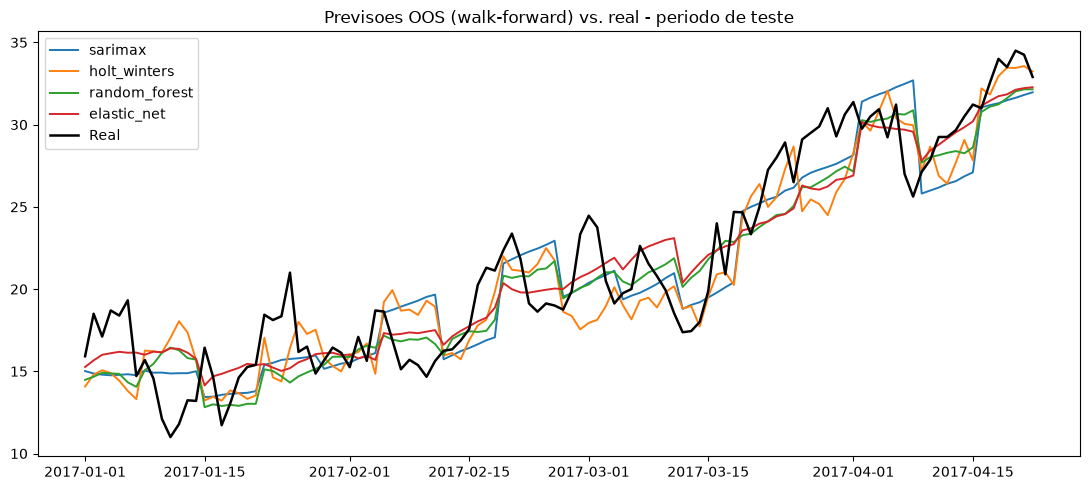

In [30]:
fig, ax = plt.subplots(figsize=(11, 5))
for slug, df in results.items():
    agg = df.groupby("forecast_date")["y_pred"].mean()
    ax.plot(agg.index, agg.values, label=slug, linewidth=1.4)
truth = cleaned.loc[results["sarimax"]["forecast_date"].min():results["sarimax"]["forecast_date"].max(), tc.TARGET]
ax.plot(truth.index, truth.values, color="black", linewidth=1.8, label="Real")
ax.set_title("Previsoes OOS (walk-forward) vs. real - periodo de teste")
ax.legend()
plt.tight_layout()
plt.show()

**Erro por passo do horizonte e previsores de referencia.** Dois previsores sem nenhum ajuste,
rodados nas mesmas origens, servem de regua: a **persistencia** (repete a temperatura do dia da
origem) e a **climatologia + anomalia** (media historica do dia do ano, suavizada em 15 dias,
somada ao desvio de hoje em relacao a essa media). Ambos so usam dados ate a origem.

In [31]:
step_mae = pd.DataFrame({slug: (df.y_true - df.y_pred).abs().groupby(df.horizon_step).mean() for slug, df in results.items()})
print("MAE por passo do horizonte:")
display(step_mae.round(2))

def persistence_fn(train_df, horizon):
    return np.repeat(train_df[tc.TARGET].iloc[-1], horizon)

def clim_anomaly_fn(train_df, horizon):
    y = train_df[tc.TARGET]
    clim = y.groupby(y.index.dayofyear).mean()
    clim = pd.concat([clim.iloc[-7:], clim, clim.iloc[:7]]).rolling(15, center=True).mean().iloc[7:-7]  # circular
    dates = pd.date_range(y.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    anomaly = y.iloc[-1] - clim.loc[y.index[-1].dayofyear]
    return clim.reindex(dates.dayofyear).to_numpy() + anomaly

ref_rows = []
for name, fn in (("persistencia", persistence_fn), ("climatologia+anomalia", clim_anomaly_fn)):
    for periodo, cfg in (("validacao", cfg_tune), ("teste", cfg_test)):
        r = tc.run_walk_forward(fn, cleaned, cfg, name)
        ref_rows.append({"referencia": name, "periodo": periodo, "mae": tc.mae(r.y_true, r.y_pred)})
print("Previsores de referencia (sem ajuste, mesmas origens):")
display(pd.DataFrame(ref_rows).pivot(index="referencia", columns="periodo", values="mae").round(3))

MAE por passo do horizonte:


,sarimax,holt_winters,random_forest,elastic_net
horizon_step,,,,
1,1.09,1.07,1.39,1.33
2,1.45,1.89,1.39,1.51
3,1.99,2.32,1.99,1.98
4,2.54,2.81,2.35,2.25
5,2.48,2.66,2.13,1.94
6,2.54,2.32,2.52,2.09
7,2.72,2.50,2.26,2.14


Previsores de referencia (sem ajuste, mesmas origens):


periodo,teste,validacao
referencia,,
climatologia+anomalia,2.097,0.727
persistencia,2.350,1.077


**Discussao (§6):**

- **Ranking:** Elastic Net (1.891) < Random Forest (2.005) < SARIMAX (2.116) < Holt-Winters
  (2.224). Entre o 1o e o 4o colocados ha 0.33 °C, ou ~15% do MAE.
- **Contra as referencias:** os quatro vencem a persistencia (2.350), mas **so Elastic Net e
  Random Forest vencem a climatologia + anomalia (2.097)**, um previsor sem nenhum ajuste.
  SARIMAX e Holt-Winters ficam piores que ele. O padrao desta base eh que, em 7 dias, ganha quem
  combina bem o **desvio de hoje em relacao ao normal** (persistencia) com o **ciclo anual**.
- **Por horizonte:** em `h=1`, SARIMAX e Holt-Winters sao os melhores (1.09 e 1.07, contra 1.33 e
  1.39 dos tabulares). O SARIMAX vencedor eh `(0,1,0)`, um passeio aleatorio com Fourier e
  externas, e o Holt-Winters tem `alpha` ~0.76: no primeiro passo, os dois sao praticamente
  "amanha = hoje, corrigido pelo ciclo", o que eh dificil de bater a 1 dia. A partir de `h=4` o
  Elastic Net eh o melhor (2.14 a 2.25), e o SARIMAX chega a 2.72 em `h=7`: num passeio
  aleatorio o erro se acumula a cada passo, enquanto o Elastic Net tem termos (`doy_cos`,
  `lag_365`, medias moveis) que puxam a previsao de volta para o nivel sazonal.
- **Vies (Secao H):** todos subestimam a temperatura do periodo de teste, sobretudo em marco, o
  mes de subida mais rapida da curva anual. O Elastic Net tem o menor vies (+0.27 °C, contra
  +0.56 a +0.67 dos demais).
- **Elastic Net x Random Forest (mesmas features):** arvores nao extrapolam alem dos valores vistos
  no treino. Com 2017 comecando mais quente que o historico (tendencia em alta no fim de 2016,
  Secao D), o RF fica preso a niveis antigos (vies +0.67), enquanto o Elastic Net, linear,
  acompanha o nivel pelos lags. Eh uma hipotese coerente com o vies por mes, nao testada isoladamente.
- **Validacao x teste:** o MAE de teste (1.89 a 2.22) eh o dobro do de validacao (0.77 a 1.20), e
  o motivo eh o periodo, nao os modelos: a propria persistencia vai de 1.08 na validacao (set a
  dez) para 2.35 no teste (jan a abr). O ranking tambem muda: na validacao, o RF (0.772) e o SARIMAX
  (0.786) ficavam a frente do Elastic Net (1.035). Com 112 previsoes em uma unica estacao, o
  ranking desta base deve ser lido com cautela.

## H. Residuos (§7)

Para cada modelo: `e = y_true - y_pred` (OOS, pooled entre as 16 origens x 7 passos de
horizonte).

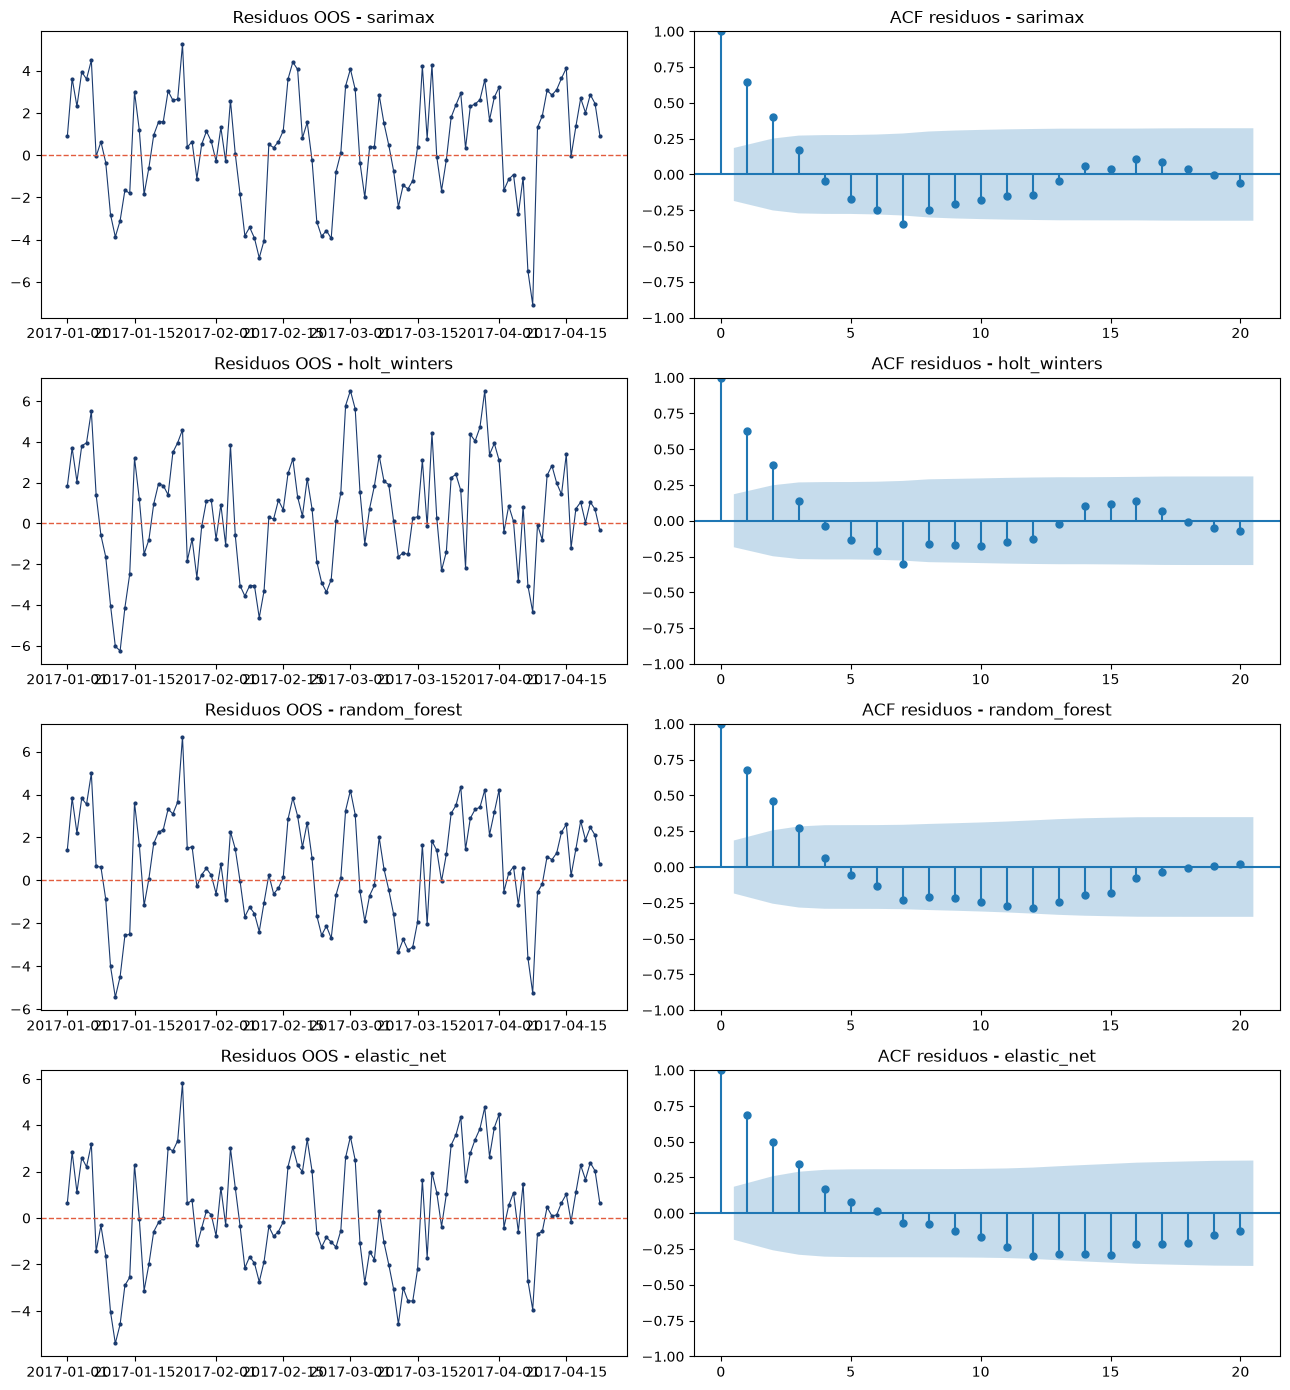

,lb_stat,lb_pvalue,modelo,lag
0,95.189651,1.059439e-17,sarimax,7
1,118.024729,1.531995e-18,sarimax,14
2,84.005340,2.094489e-15,holt_winters,7
3,101.061489,2.967725e-15,holt_winters,14
4,94.971806,1.174750e-17,random_forest,7
5,146.716935,3.256065e-24,random_forest,14
6,102.140083,3.897253e-19,elastic_net,7
7,147.188699,2.621175e-24,elastic_net,14


In [32]:
ljung_rows = []
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
for i, (slug, df) in enumerate(results.items()):
    resid = df["y_true"] - df["y_pred"]
    axes[i, 0].plot(df["forecast_date"], resid, color="#1a3a6e", linewidth=0.8, marker="o", markersize=2)
    axes[i, 0].axhline(0, color="#e25c3e", linestyle="--", linewidth=1)
    axes[i, 0].set_title(f"Residuos OOS - {slug}")

    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(resid, lags=20, ax=axes[i, 1], title=f"ACF residuos - {slug}")

    lb = tc.ljung_box_table(resid, lags=(7, 14))
    lb["modelo"] = slug
    lb["lag"] = lb.index
    ljung_rows.append(lb.reset_index(drop=True))

    tc.save_predictions(df, DATA_DIR, BASE_ID, slug)
    tc.save_residuals(df, DATA_DIR, BASE_ID, slug)

plt.tight_layout()
plt.show()

ljung_df = pd.concat(ljung_rows, ignore_index=True)
ljung_df.to_csv(DATA_DIR / f"ljung_box_{BASE_ID}.csv", index=False)
display(ljung_df)

In [33]:
bias_rows = []
for slug, df in results.items():
    e = df.y_true - df.y_pred
    bias_rows.append({"modelo": slug, "vies_media": e.mean(), "mediana": e.median(), "desvio": e.std(),
                      "pct_previsoes_abaixo_do_real": (e > 0).mean()})
bias_df = pd.DataFrame(bias_rows)
bias_df.to_csv(DATA_DIR / f"residual_bias_{BASE_ID}.csv", index=False)
print("Vies dos residuos OOS (real - previsto; positivo = modelo subestima):")
display(bias_df.round(3))
print("Vies medio por mes previsto:")
display(pd.DataFrame({slug: (df.y_true - df.y_pred).groupby(df.forecast_date.dt.month).mean() for slug, df in results.items()}).round(2))

# Ljung-Box por passo: para cada h, a serie das 16 origens (uma por semana) -- sem misturar passos
lb_step_rows = []
for step in (1, 7):
    for slug, df in results.items():
        e = (df.y_true - df.y_pred)[df.horizon_step == step].reset_index(drop=True)
        lb = tc.ljung_box_table(e, lags=(1, 4))
        lb_step_rows.append({"passo_h": step, "modelo": slug, "n": len(e),
                             "p_valor_lag1": lb["lb_pvalue"].iloc[0], "p_valor_lag4": lb["lb_pvalue"].iloc[1]})
lb_step_df = pd.DataFrame(lb_step_rows)
lb_step_df.to_csv(DATA_DIR / f"ljung_box_by_step_{BASE_ID}.csv", index=False)
print("Ljung-Box por passo do horizonte:")
display(lb_step_df.round(3))

Vies dos residuos OOS (real - previsto; positivo = modelo subestima):


,modelo,vies_media,mediana,desvio,pct_previsoes_abaixo_do_real
0,sarimax,0.563,0.652,2.521,0.625
1,holt_winters,0.591,0.725,2.694,0.625
2,random_forest,0.672,0.703,2.361,0.625
3,elastic_net,0.268,0.112,2.311,0.518


Vies medio por mes previsto:


,sarimax,holt_winters,random_forest,elastic_net
forecast_date,,,,
1,0.89,0.46,1.04,0.04
2,-0.48,-0.33,0.11,0.14
3,1.08,1.73,0.83,0.44
4,0.70,0.33,0.65,0.50


Ljung-Box por passo do horizonte:


,passo_h,modelo,n,p_valor_lag1,p_valor_lag4
0,1,sarimax,16,0.929,0.952
1,1,holt_winters,16,0.577,0.843
2,1,random_forest,16,0.329,0.815
3,1,elastic_net,16,0.675,0.618
4,7,sarimax,16,0.015,0.003
5,7,holt_winters,16,0.001,0.000
6,7,random_forest,16,0.085,0.045
7,7,elastic_net,16,0.444,0.207


**Interpretacao dos residuos (§7):**

- **Vies:** os quatro modelos **subestimam** o periodo de teste (residuo medio positivo): RF
  +0.67 °C, Holt-Winters +0.59, SARIMAX +0.56, Elastic Net +0.27. Em SARIMAX, HW e RF, 62.5% das
  previsoes ficam abaixo do real; no Elastic Net, 52%. O vies se concentra em **marco**
  (SARIMAX +1.08, HW +1.73, RF +0.83, EN +0.44), o mes de subida mais rapida da curva anual: os
  modelos apoiados em persistencia ficam "atrasados" em relacao ao aquecimento.
- **Variabilidade:** o desvio do residuo vai de 2.3 °C (EN, RF) a 2.7 °C (HW), e o erro cresce com
  o horizonte (tabela de MAE por passo, Secao G).
- **Autocorrelacao, serie "pooled" (`lag=7` e `14`):** p-valores ~0 nos quatro modelos. Mas essa
  serie empilha os passos `h=1..7` de origens consecutivas, entao parte da autocorrelacao vem do
  proprio desenho (o erro cresce de `h=1` a `h=7` e volta a cair na origem seguinte), e nao do
  modelo.
- **Ljung-Box por passo** (16 residuos por passo, um por origem semanal): em `h=1` nenhum modelo
  rejeita ruido branco (p >= 0.33), ou seja, o erro de 1 dia nao carrega padrao de uma semana para
  a seguinte. Em `h=7`, SARIMAX (p = 0.015 no lag 1) e Holt-Winters (p = 0.001) rejeitam, o RF
  fica na fronteira (p = 0.085 no lag 1 e 0.045 no lag 4) e o Elastic Net nao rejeita (p = 0.44):
  os erros de 7 dias do SARIMAX e do HW tem o mesmo sinal por varias semanas seguidas, o mesmo
  "atraso" no aquecimento visto no vies. **Limitacao:** com 16 pontos o teste tem pouco poder, e a
  ausencia de rejeicao nao prova ruido branco.

## I. Importancia e persistencia dos modelos finais (§8, ADR-0005)

Reajustamos cada modelo **uma unica vez**, no treino completo pre-teste (ate 2016-12-31),
para a tabela de importancia e para os artefatos persistidos (`../artifacts/base_01/{modelo}.pkl` +
`{modelo}_meta.json`, conforme `artifacts/README.md` e ADR-0005) — distinto dos 16 refits do
walk-forward acima (cada um usado so para gerar a previsao daquela origem).

In [34]:
import joblib
from sklearn.inspection import permutation_importance

full_train = cleaned.loc[:FIRST_ORIGIN_TEST]

sx_p = best_params["sarimax"]
t0 = time.time()
sarimax_final = tc.fit_sarimax(full_train, sx_p, maxiter=200)
sarimax_seconds = time.time() - t0
sarimax_coef = pd.DataFrame({"termo": sarimax_final.param_names, "coeficiente": sarimax_final.params.values, "p_valor": sarimax_final.pvalues.values}).sort_values("p_valor")
sarimax_coef.to_csv(DATA_DIR / f"importance_sarimax_{BASE_ID}.csv", index=False)
joblib.dump(sarimax_final, ARTIFACT_DIR / "sarimax.pkl")
# registro por execucao (spec de modelos §7), comum aos quatro _meta.json
test_mae = mae_df.set_index("modelo")["mae"]
def run_record(slug, fit_seconds):
    return {"fit_seconds": round(fit_seconds, 3), "mae_validacao": float(best_mae[slug]), "mae_teste": float(test_mae[slug]),
            "horizon": H, "test_origins": len(tc.build_origins(cfg_test))}

tc.save_meta(ARTIFACT_DIR, BASE_ID, "sarimax", sx_p, RANDOM_STATE, {
    **run_record("sarimax", sarimax_seconds),
    "training": tc.training_window(sarimax_final.fittedvalues.index),
    "exog": list(sarimax_final.model.exog_names or []),
    "aic": float(sarimax_final.aic), "bic": float(sarimax_final.bic),
})
display(sarimax_coef)

,termo,coeficiente,p_valor
9,sigma2,2.668118,0.000000e+00
4,humidity_lag1,0.024291,2.416662e-07
8,ma.S.L7,-0.346906,1.072053e-02
1,fourier_cos_1,-9.712399,1.073116e-02
7,ar.S.L7,0.320458,1.873026e-02
5,wind_speed_lag1,-0.019182,5.693036e-02
3,fourier_cos_2,-2.710124,1.373264e-01
2,fourier_sin_2,-1.748374,3.245067e-01
6,meanpressure_lag1,0.015489,5.418751e-01
0,fourier_sin_1,-0.025621,9.941356e-01


Parametros de suavizacao: {'smoothing_level': 0.7601, 'smoothing_trend': 0.0, 'smoothing_seasonal': 0.0}
Inclinacao final: 0.0118 °C/dia (4.32 °C/ano; +0.08 °C ao longo de h=7)
Amplitude do perfil sazonal: 25.39 °C


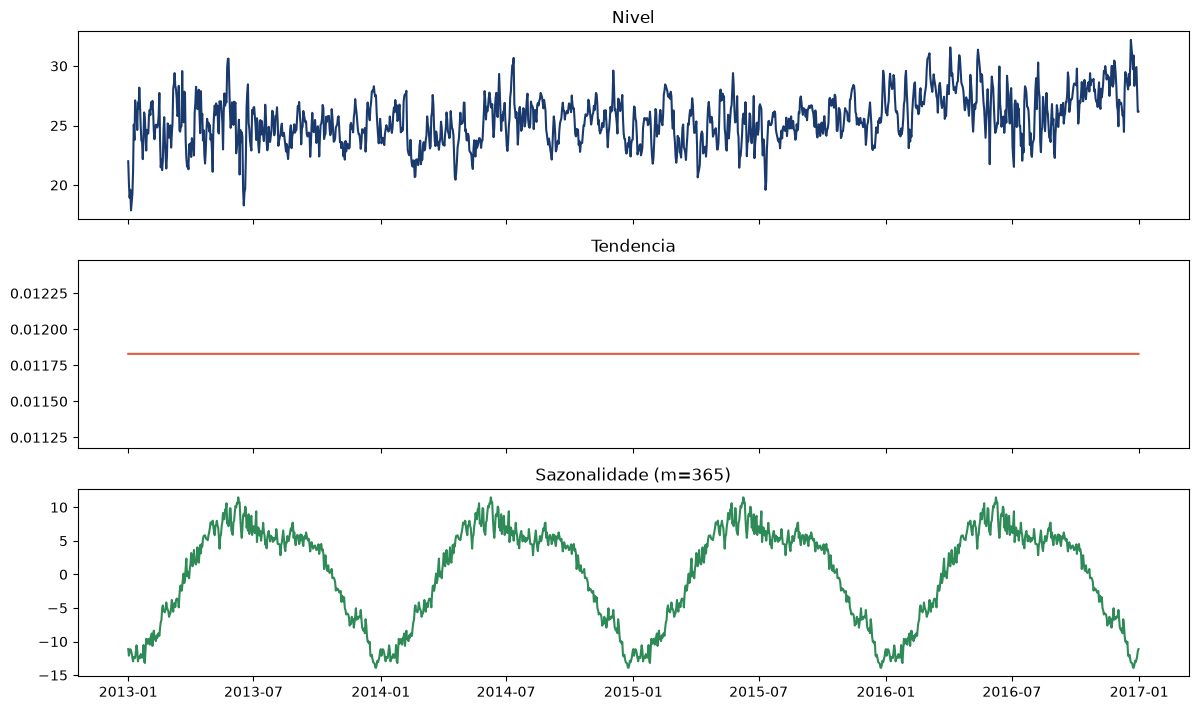

WindowsPath('../artifacts/base_01/holt_winters_meta.json')

In [35]:
hw_p = best_params["holt_winters"]
t0 = time.time()
hw_final = fit_hw(full_train[tc.TARGET], hw_p)
hw_seconds = time.time() - t0
print("Parametros de suavizacao:", {k: round(float(v), 4) for k, v in hw_final.params.items() if "smoothing" in k and v == v})
if hw_p["trend"] is not None:
    slope = float(hw_final.trend.iloc[-1])
    print(f"Inclinacao final: {slope:.4f} °C/dia ({slope * 365:.2f} °C/ano; {slope * H:+.2f} °C ao longo de h={H})")
if hw_p["seasonal"] is not None:
    print(f"Amplitude do perfil sazonal: {float(hw_final.season.max() - hw_final.season.min()):.2f} °C")

# so plota os componentes que o modelo vencedor tem (trend/seasonal podem ser None)
components = [("Nivel", hw_final.level, "#1a3a6e")]
if hw_p["trend"] is not None:
    components.append(("Tendencia", hw_final.trend, "#e25c3e"))
if hw_p["seasonal"] is not None:
    components.append((f"Sazonalidade (m={hw_p['seasonal_periods']})", hw_final.season, "#2e8b57"))
fig, axes = plt.subplots(len(components), 1, figsize=(12, 2.4 * len(components)), sharex=True, squeeze=False)
for ax, (title, series, color) in zip(axes[:, 0], components):
    ax.plot(full_train.index, series, color=color)
    ax.set_title(title)
plt.tight_layout()
plt.show()

joblib.dump(hw_final, ARTIFACT_DIR / "holt_winters.pkl")
smoothing = {g: float(hw_final.params[k]) for g, k in (("alpha", "smoothing_level"), ("beta", "smoothing_trend"), ("gamma", "smoothing_seasonal"))
             if hw_final.params[k] == hw_final.params[k]}  # NaN = componente ausente
tc.save_meta(ARTIFACT_DIR, BASE_ID, "holt_winters", hw_p, RANDOM_STATE, {
    **run_record("holt_winters", hw_seconds),
    "training": tc.training_window(full_train.index),
    "smoothing": smoothing,
    "aic": float(hw_final.aic), "bic": float(hw_final.bic),
})

In [36]:
rf_p = best_params["random_forest"]
feat_all = tc.build_features(full_train).dropna()
feature_cols = [c for c in feat_all.columns if c != tc.TARGET]
X, y = feat_all[feature_cols], feat_all[tc.TARGET]
t0 = time.time()
rf_final = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_p).fit(X, y)
rf_seconds = time.time() - t0

native_imp = pd.Series(rf_final.feature_importances_, index=feature_cols, name="importancia_nativa")
perm = permutation_importance(rf_final, X, y, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols, name="importancia_permutation")
rf_imp = pd.concat([native_imp, perm_imp], axis=1).sort_values("importancia_nativa", ascending=False)
rf_imp.to_csv(DATA_DIR / f"importance_random_forest_{BASE_ID}.csv")
joblib.dump(rf_final, ARTIFACT_DIR / "random_forest.pkl")
tc.save_meta(ARTIFACT_DIR, BASE_ID, "random_forest", rf_p, RANDOM_STATE, {
    **run_record("random_forest", rf_seconds),
    "training": tc.training_window(X.index),
    "features": feature_cols,  # ordem exigida pelo predict ao recarregar o .pkl
    "n_features": len(feature_cols),
})
display(rf_imp.head(10))

,importancia_nativa,importancia_permutation
meantemp_lag_1,0.185853,0.116412
meantemp_roll_mean_7,0.156825,0.057568
meantemp_lag_2,0.123518,0.033265
meantemp_lag_3,0.114758,0.018514
doy_cos,0.077184,0.015249
meantemp_lag_365,0.066183,0.007397
meantemp_lag_7,0.062525,0.007542
meantemp_roll_mean_30,0.050238,0.011855
meanpressure_lag_1,0.040453,0.008182
meanpressure_lag_7,0.018439,0.003011


In [37]:
en_p = best_params["elastic_net"]
t0 = time.time()
en_final = make_pipeline(StandardScaler(), ElasticNet(random_state=RANDOM_STATE, max_iter=10000, **en_p)).fit(X, y)
en_seconds = time.time() - t0
enet = en_final.named_steps["elasticnet"]
en_coef = pd.Series(enet.coef_, index=feature_cols, name="coeficiente_padronizado").sort_values(key=abs, ascending=False)
en_coef_df = en_coef.to_frame()
en_coef_df["zerado"] = en_coef_df["coeficiente_padronizado"] == 0
en_coef_df.to_csv(DATA_DIR / f"importance_elastic_net_{BASE_ID}.csv")
joblib.dump(en_final, ARTIFACT_DIR / "elastic_net.pkl")
tc.save_meta(ARTIFACT_DIR, BASE_ID, "elastic_net", en_p, RANDOM_STATE, {
    **run_record("elastic_net", en_seconds),
    "training": tc.training_window(X.index),
    "pipeline": "StandardScaler -> ElasticNet (o .pkl inclui o scaler ajustado no treino)",
    "features": feature_cols,  # ordem exigida pelo predict ao recarregar o .pkl
    "n_features_total": len(feature_cols),
    "n_features_zeradas": int(en_coef_df["zerado"].sum()),
})
print(f"{en_coef_df['zerado'].sum()} / {len(feature_cols)} coeficientes zerados (l1_ratio={en_p['l1_ratio']})")
display(en_coef_df.head(12))

10 / 28 coeficientes zerados (l1_ratio=0.5)


,coeficiente_padronizado,zerado
meantemp_lag_1,2.687467,False
meantemp_lag_2,0.884460,False
meantemp_roll_mean_7,0.883597,False
doy_cos,-0.674571,False
meantemp_lag_365,0.486572,False
humidity_lag_1,-0.451708,False
meantemp_roll_mean_30,0.406824,False
meantemp_lag_3,0.329287,False
meantemp_lag_14,0.304695,False
meantemp_lag_7,0.179620,False


**Variaveis externas lado a lado (§8).** Importancia de cada externa nos tres modelos que as usam,
e as correlacoes que explicam os sinais. As correlacoes sao calculadas so no treino (ate
2016-12-31); a coluna contemporanea serve **apenas para interpretacao** e nao entra em nenhum modelo.

In [38]:
ext_cols = [c for c in feature_cols if c.split("_lag")[0] in tc.EXTERNALS]
sx_terms = sarimax_coef.set_index("termo")
ext_table = pd.DataFrame({
    "rf_nativa": rf_imp["importancia_nativa"],
    "rank_rf_nativa": rf_imp["importancia_nativa"].rank(ascending=False).astype(int),
    "rf_permutation": rf_imp["importancia_permutation"],
    "rank_rf_permutation": rf_imp["importancia_permutation"].rank(ascending=False).astype(int),
    "en_coef_padronizado": en_coef,
}).loc[ext_cols]
ext_table["sarimax_coef"] = [sx_terms["coeficiente"].get(c.replace("_lag_1", "_lag1")) if c.endswith("_lag_1") else np.nan for c in ext_cols]
ext_table["sarimax_p_valor"] = [sx_terms["p_valor"].get(c.replace("_lag_1", "_lag1")) if c.endswith("_lag_1") else np.nan for c in ext_cols]
display(ext_table.round(4))
print(f"Soma da importancia nativa das externas no RF: {rf_imp.loc[ext_cols, 'importancia_nativa'].sum():.1%} (de 28 features, 9 sao externas)")

dT = full_train[tc.TARGET].diff()
corr_rows = []
for col in tc.EXTERNALS:
    x = full_train[col]
    corr_rows.append({
        "externa": col,
        "nivel: T(t) x X(t-1)": full_train[tc.TARGET].corr(x.shift(1)),
        "variacao: dT(t) x dX(t-1)": dT.corr(x.diff().shift(1)),
        "variacao contemporanea: dT(t) x dX(t)": dT.corr(x.diff()),
    })
display(pd.DataFrame(corr_rows).set_index("externa").round(3))

,rf_nativa,rank_rf_nativa,rf_permutation,rank_rf_permutation,en_coef_padronizado,sarimax_coef,sarimax_p_valor
humidity_lag_1,0.0078,17,0.0076,8,-0.4517,0.0243,0.0000
humidity_lag_7,0.0049,19,0.0024,18,0.0000,NaN,NaN
humidity_lag_14,0.0044,20,0.0026,17,-0.0000,NaN,NaN
wind_speed_lag_1,0.0015,24,0.0013,24,-0.1006,-0.0192,0.0569
wind_speed_lag_7,0.0017,23,0.0015,23,0.0000,NaN,NaN
wind_speed_lag_14,0.0015,25,0.0012,25,0.0000,NaN,NaN
meanpressure_lag_1,0.0405,9,0.0082,7,-0.1337,0.0155,0.5419
meanpressure_lag_7,0.0184,10,0.0030,15,-0.0000,NaN,NaN
meanpressure_lag_14,0.0119,13,0.0028,16,-0.0000,NaN,NaN


Soma da importancia nativa das externas no RF: 9.3% (de 28 features, 9 sao externas)


,nivel: T(t) x X(t-1),variacao: dT(t) x dX(t-1),variacao contemporanea: dT(t) x dX(t)
externa,,,
humidity,-0.541,0.135,-0.658
wind_speed,0.287,-0.081,0.062
meanpressure,-0.868,0.031,-0.312


**Sintese de importancia (§8):**

- **SARIMAX (coeficientes, sinal, magnitude, significancia).** Das externas, so a umidade eh
  significativa: `humidity_lag1` = +0.024 (p < 0.001), ou +0.24 °C para cada 10 pontos percentuais
  de umidade a mais no dia anterior. `wind_speed_lag1` (-0.02) fica na fronteira (p ~ 0.05) e
  `meanpressure_lag1` nao eh significativa (p ~ 0.5). Do ciclo anual, so o primeiro harmonico eh
  individualmente significativo (`fourier_cos_1` ~ -9.7, p ~ 0.01): com `d=1` os termos de Fourier
  entram em diferencas diarias, que variam pouco, e os demais harmonicos tem erro padrao alto
  (o `K=2` escolhido na validacao fica com 4 termos, dos quais so 1 significativo). Os termos semanais `ar.S.L7` (+0.32) e
  `ma.S.L7` (-0.35) sao individualmente significativos (p ~ 0.01-0.02), mas tem sinais opostos
  e magnitudes parecidas, entao quase se cancelam: o efeito liquido eh pequeno, coerente com o
  ganho pequeno que trouxeram na busca (0.802 -> 0.786). `sigma2` ~ 2.7 equivale a um erro de 1 passo
  de ~1.6 °C.
- **Holt-Winters (nivel, tendencia, sazonalidade):** `alpha` = 0.76, entao o nivel acompanha de
  perto a ultima observacao; `beta` = 0, entao a inclinacao fica fixa no valor da inicializacao
  (~0.012 °C/dia, que soma so +0.08 °C nos 7 dias do horizonte); `gamma` = 0, entao o perfil anual
  (amplitude ~25 °C) fica congelado. Na pratica o modelo eh "nivel recente + curva anual fixa".
- **Random Forest:** `meantemp_lag_1` lidera (0.19 nativa, 0.12 permutation), seguida da media
  movel de 7 dias e dos lags 2 e 3. Depois vem a informacao anual (`doy_cos`, `meantemp_lag_365`).
  As 9 externas somam ~9% da importancia nativa. A mais util eh `meanpressure_lag_1` (9a nativa, 7a
  permutation). `humidity_lag_1` eh 17a na nativa mas 8a na permutation: a importancia nativa
  (reducao de impureza) divide o credito entre features correlacionadas, enquanto a permutation
  mede a perda ao quebrar so aquela feature. **Limitacao:** a permutation foi calculada na propria
  amostra de treino, o que tende a superestimar a importancia.
- **Elastic Net (coeficientes padronizados):** `meantemp_lag_1` (+2.69) domina; depois vem
  `meantemp_lag_2` e a media de 7 dias (~+0.88), `doy_cos` (-0.67: cosseno maximo no inicio de
  janeiro, o vale do ano) e `meantemp_lag_365` (+0.49). `humidity_lag_1` (-0.45) eh a 6a feature e a
  unica externa com peso relevante. 10 de 28 coeficientes zerados: **todos os lags de 7 e 14 dias
  das externas**, o calendario semanal (`dow_sin`, `dow_cos`), `doy_sin` e `meantemp_lag_21`. So o
  valor mais recente de cada externa sobrevive, e o zeramento do calendario semanal confirma a
  ausencia de ciclo semanal (`Fs(7)` = 0.05).
- **Concordancia:** nos dois modelos tabulares, persistencia (lags curtos e media de 7 dias) vem
  primeiro, ciclo anual em seguida e externas por ultimo. `meantemp_lag_1` nao existe no SARIMAX
  nem no HW; neles, o papel equivalente eh do `d=1` (SARIMAX) e do `alpha` alto (HW).

**O sinal da umidade: +0.024 no SARIMAX, -0.45 no Elastic Net.** Nao eh contradicao, porque os
dois modelos respondem perguntas diferentes (tabela de correlacoes acima):

- **Em nivel** (Elastic Net, que modela a temperatura junto com os lags): dias mais umidos sao mais
  frios (correlacao -0.54 entre `T(t)` e a umidade de ontem), por causa da moncao e do inverno.
- **Em variacao** (SARIMAX com `d=1`, que modela a mudanca diaria): no mesmo dia, umidade subindo
  esfria (-0.66), mas no **dia seguinte** a temperatura se recupera (+0.14 entre `dT(t)` e
  `dU(t-1)`). O coeficiente positivo captura esse rebote.
- A pressao segue a mesma logica: em nivel ela eh fortemente ligada a temperatura (-0.87), mas
  porque ambas seguem a estacao (pressao alta no inverno). Esse efeito o Fourier ja captura no
  SARIMAX; em variacao a correlacao eh ~0 (+0.03), dai o p-valor alto. No RF, que nao tem Fourier
  explicito, a pressao funciona como um marcador do ciclo anual.

**Disponibilidade temporal das externas (retomando a Secao B e o ADR-0003).** As tres externas sao
`lag_only`: na origem `t` so conhecemos seus valores ate `t`, e nenhum modelo usa o valor do dia
previsto. Isso tem uma consequencia direta: no treino, `humidity_lag_1` eh de fato a umidade da
vespera, mas na previsao de `t+h` ela fica **congelada** no valor de `t`, cada vez mais velha
conforme `h` cresce. Por isso o ganho das externas tende a se concentrar nos primeiros passos, o que
ajuda a explicar o peso pequeno que elas tem (e, no SARIMAX, a etapa 4 da busca: sem os lags o MAE
de validacao foi ate um pouco menor). Usar uma previsao meteorologica disponivel na origem (§4.1)
resolveria isso, mas ela nao faz parte da base.

**Verificacao dos artifacts (ADR-0005, `artifacts/README.md`).** Cada `.pkl` eh relido do disco
e comparado ao modelo em memoria (mesmas previsoes / mesmos parametros), e cada `_meta.json`
precisa ter os campos do README (`base_id`, `model`, hiperparametros, data/hora, seed, versoes de
libs) mais o registro por execucao da spec de modelos (§7: tempo de ajuste, janela de treino,
metricas). Os artifacts ficam fora do git (`.gitignore`) e sao regenerados ao rodar o notebook.

Para reutilizar um modelo tabular, a ordem das colunas vem do meta:

```python
meta = json.loads((ARTIFACT_DIR / "random_forest_meta.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACT_DIR / "random_forest.pkl")
y_hat = model.predict(tc.build_features(df).dropna()[meta["features"]])
```

In [39]:
REQUIRED_META = {"base_id", "model", "artifact", "hyperparams", "trained_at", "random_state", "library_versions",
                 "fit_seconds", "training", "mae_validacao", "mae_teste"}
in_memory = {"sarimax": sarimax_final, "holt_winters": hw_final, "random_forest": rf_final, "elastic_net": en_final}

def reproduces(slug, loaded, original):
    if slug in ("random_forest", "elastic_net"):
        return np.allclose(loaded.predict(X), original.predict(X))
    if slug == "holt_winters":
        return np.allclose(loaded.forecast(H), original.forecast(H))
    return np.allclose(loaded.params, original.params) and np.allclose(loaded.fittedvalues, original.fittedvalues)

check_rows = []
for slug, original in in_memory.items():
    pkl = ARTIFACT_DIR / f"{slug}.pkl"
    meta = json.loads((ARTIFACT_DIR / f"{slug}_meta.json").read_text(encoding="utf-8"))
    check_rows.append({
        "modelo": slug,
        "pkl_MB": round(pkl.stat().st_size / 1e6, 1),
        "campos_faltando": ", ".join(sorted(REQUIRED_META - meta.keys())) or "-",
        "recarregado_reproduz": bool(reproduces(slug, joblib.load(pkl), original)),
        "treino": f"{meta['training']['start']} a {meta['training']['end']} ({meta['training']['n_obs']} obs)",
        "fit_seconds": meta["fit_seconds"],
    })
artifact_check = pd.DataFrame(check_rows)
display(artifact_check)
assert artifact_check["recarregado_reproduz"].all(), "algum .pkl recarregado nao reproduz o modelo"
assert (artifact_check["campos_faltando"] == "-").all(), "algum _meta.json esta incompleto"

,modelo,pkl_MB,campos_faltando,recarregado_reproduz,treino,fit_seconds
0,sarimax,26.1,-,True,2013-01-02 a 2016-12-31 (1460 obs),1.154
1,holt_winters,0.2,-,True,2013-01-01 a 2016-12-31 (1461 obs),0.215
2,random_forest,24.8,-,True,2014-01-01 a 2016-12-31 (1096 obs),0.928
3,elastic_net,0.0,-,True,2014-01-01 a 2016-12-31 (1096 obs),0.006


## Elastic Net nesta base (estudo local)

1. **Intuicao:** mistura L1/L2; `l1_ratio=1` = Lasso (esparsidade), `l1_ratio=0` = Ridge
   (encolhimento suave). O vencedor na validacao usou `l1_ratio` intermediario.
2. **Por que padronizar:** coeficientes comparaveis entre features de escalas muito diferentes
   (°C, %, km/h, hPa); `alpha` nao e invariante a escala.
3. **HP escolhidos e efeito:** ver `alpha`/`l1_ratio` acima — parte dos coeficientes foi
   zerada, indicando que nem todas as lags/externas adicionam sinal incremental.
4. **MAE vs. Random Forest:** com a mesma matriz de features (Secao E), o Elastic Net teve o menor
   MAE de teste (1.891, contra 2.005 do RF) e o menor vies (+0.27 contra +0.67). Na validacao a
   ordem foi a inversa (1.035 contra 0.772). Hipotese para o teste: o modelo linear extrapola o
   nivel mais quente de 2017, enquanto as arvores ficam presas aos valores do treino (Secao G).
5. **Interpretacao:** os maiores coeficientes padronizados sao lags curtos do proprio alvo,
   seguidos da informacao anual (`doy_cos`, `meantemp_lag_365`) e de `humidity_lag_1`, a unica
   externa com peso relevante. Os lags de 7 e 14 dias das externas foram todos zerados, coerente
   com a disponibilidade `lag_only` (so o valor mais recente carrega informacao util; ver sintese
   da Secao I).

---

## Referencias

- [`context/plan_g1.md`](../context/plan_g1.md) — plano operacional desta base
- [`context/plan_g5.md`](../context/plan_g5.md) — plano analogo da base 5 (mesmo time de especializacao)
- `document-reference/grupo1/Pipeline SARIMAX.ipynb`, `4 - HoltWinters.ipynb` — referencia metodologica
- [`data/base_01/GRUPO1.md`](../data/base_01/GRUPO1.md) — documentacao da fonte de dados